# Multi-Sample Gradient Descent for Bézier Curve Optimization

## Key Modifications:

### 1. **Multi-Sample Gradient Averaging** (NSAMPLE=3)
Each iteration now:
- Samples **NSAMPLE=3** random points `t₁, t₂, t₃ ~ U(0,1)` along the Bézier curve
- Computes cost C(wᵢ) and gradient ∇C(wᵢ) at each point
- **Averages the gradients**: `∇̄θ = (1/NSAMPLE) Σᵢ ∇θC(wᵢ)`
- Updates θ using the averaged gradient

**Benefits:**
- More stable gradient estimates (reduced variance)
- Better exploration of the curve
- Faster convergence (samples more points per iteration)

### 2. **Multi-Panel Plotting**
When plotting (every PLOT_EVERY iterations):
- Shows **NSAMPLE subplots** side-by-side
- Each subplot displays the trajectory for one sampled t value
- Easy comparison of behavior at different points along the curve

### 3. **Settings**
- `NSAMPLE = 3`: Number of samples per iteration (adjustable)
- `MAX_ITERS = 5000`: Maximum iterations
- `LR = 1e-3`: Learning rate
- `PLOT_EVERY = 5`: Plot frequency

Starting FIXED optimization with NSAMPLE=3 samples per iteration...
iter 001 | t=[0.355, 0.622, 0.482] | C_avg=1.860e+00 | mean_cost=1.671e+00 | ‖grad‖=5.347e+01 | Δθ=1.673e-02
iter 001 | t=[0.355, 0.622, 0.482] | C_avg=1.860e+00 | mean_cost=1.671e+00 | ‖grad‖=5.347e+01 | Δθ=1.673e-02


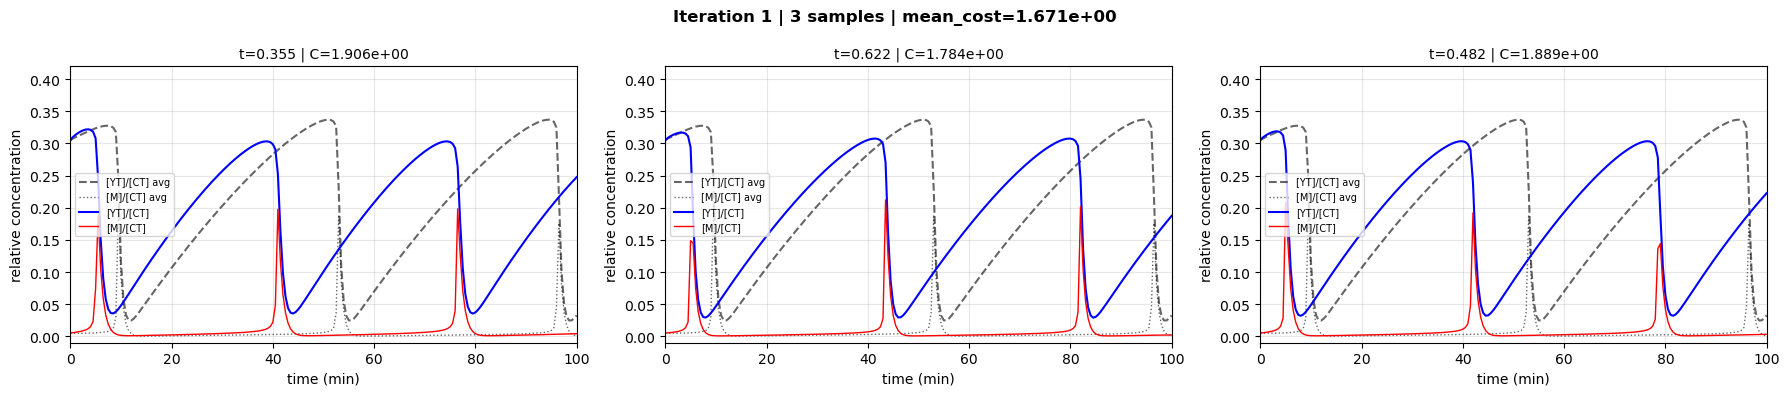

iter 050 | t=[0.654, 0.334, 0.855] | C_avg=1.829e+00 | mean_cost=1.532e+00 | ‖grad‖=3.889e+00 | Δθ=3.889e-03


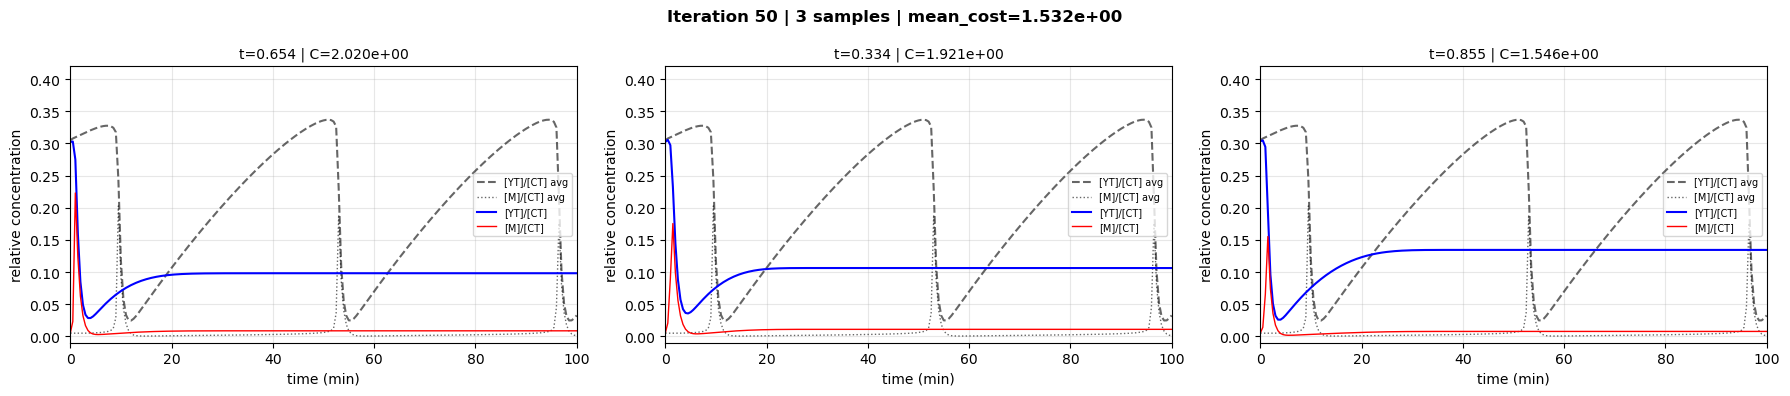

iter 100 | t=[0.403, 0.149, 0.947] | C_avg=1.526e+00 | mean_cost=1.187e+00 | ‖grad‖=5.652e-01 | Δθ=5.652e-04


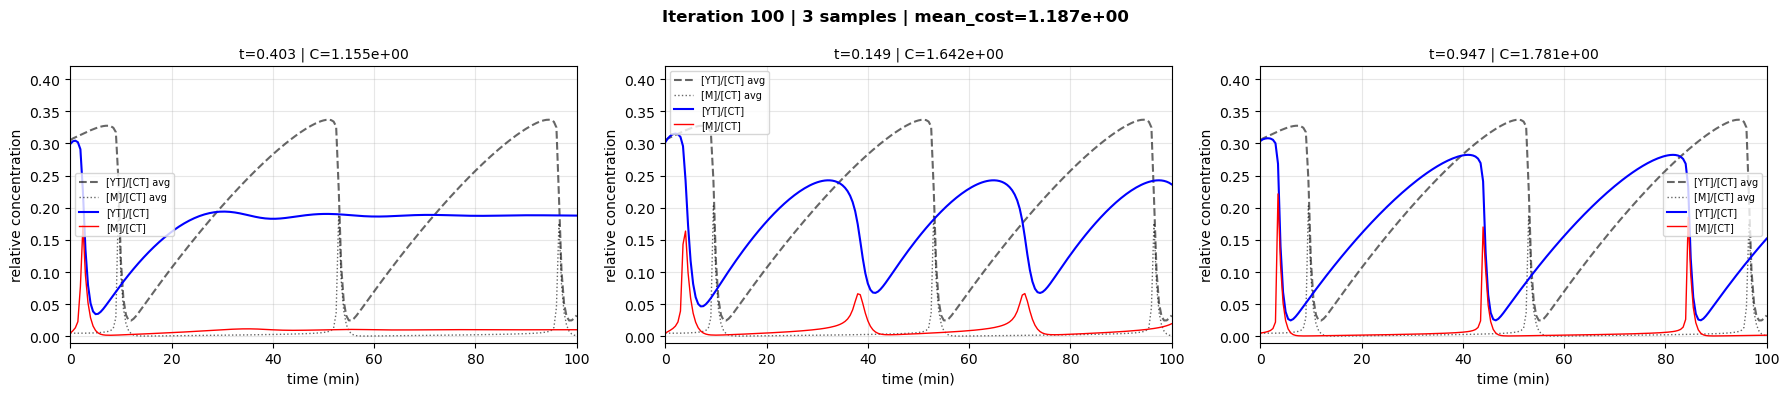

iter 150 | t=[0.763, 0.951, 0.309] | C_avg=1.358e+00 | mean_cost=1.091e+00 | ‖grad‖=4.254e+00 | Δθ=4.254e-03


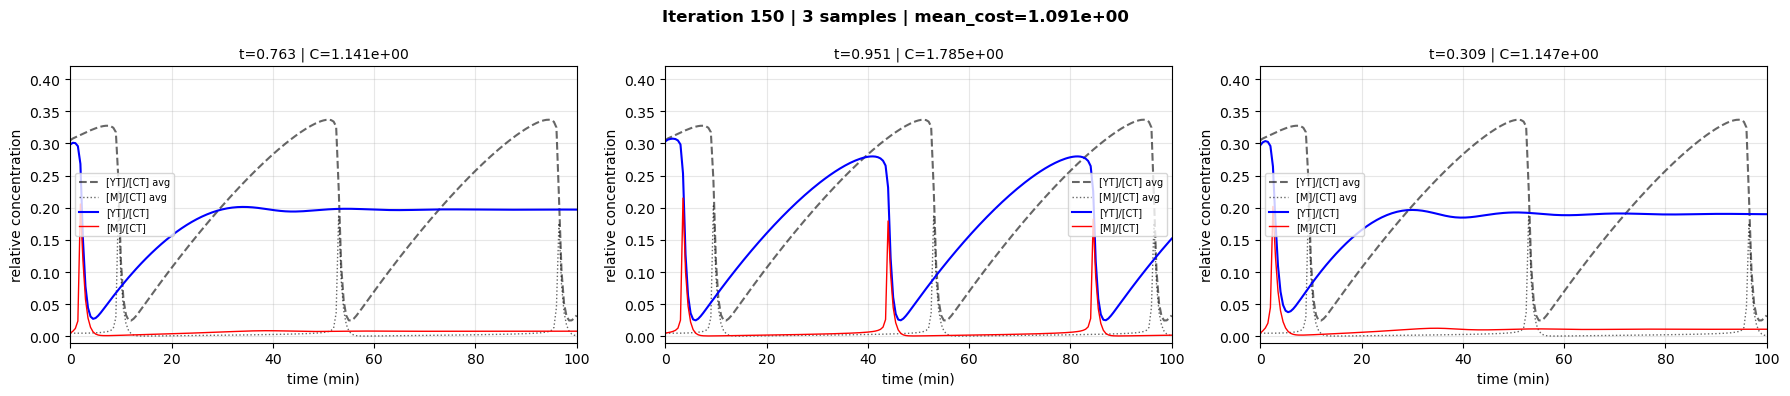

iter 200 | t=[0.516, 0.953, 0.154] | C_avg=1.480e+00 | mean_cost=1.063e+00 | ‖grad‖=5.599e+00 | Δθ=5.599e-03


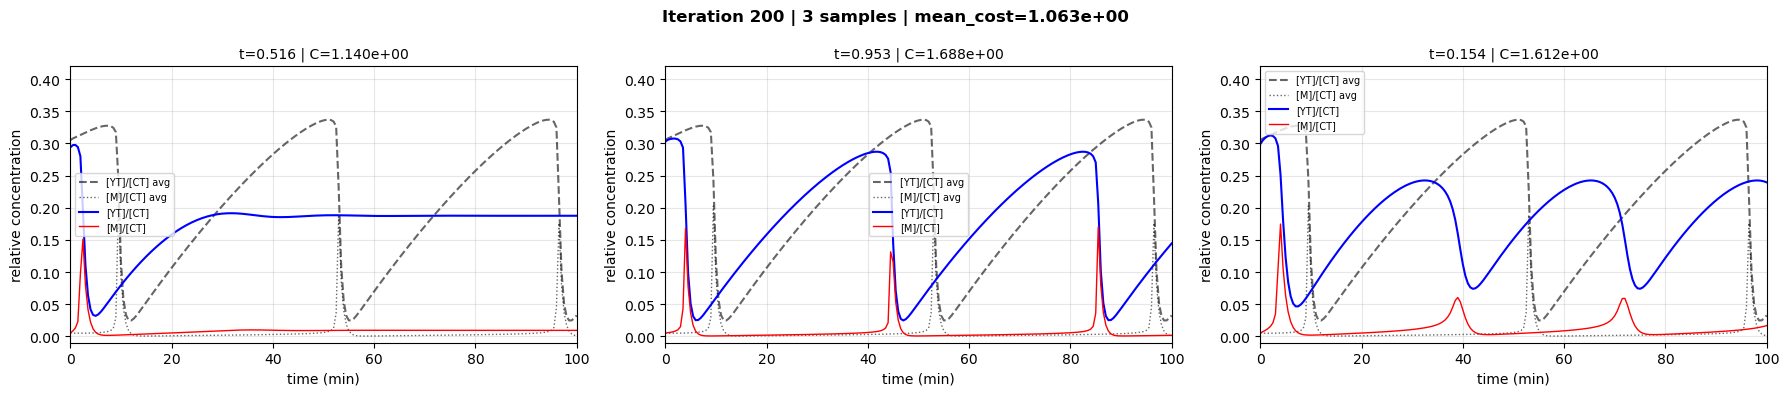

iter 250 | t=[0.742, 0.776, 0.014] | C_avg=1.546e+00 | mean_cost=1.234e+00 | ‖grad‖=3.114e+00 | Δθ=3.114e-03


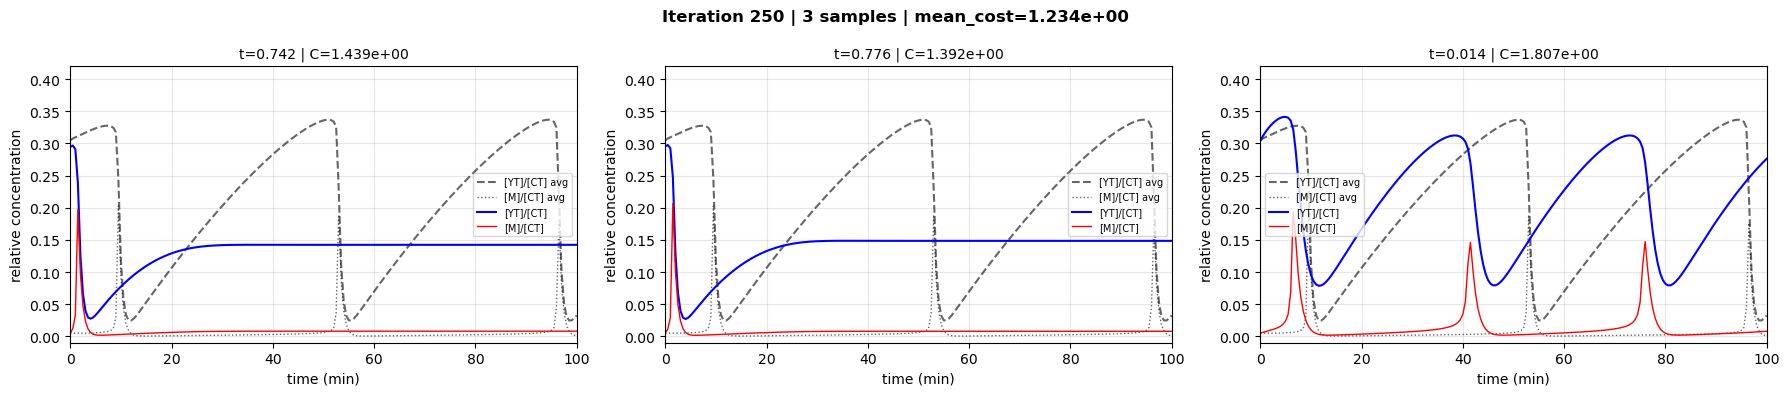

iter 300 | t=[0.360, 0.927, 0.485] | C_avg=1.368e+00 | mean_cost=1.211e+00 | ‖grad‖=4.293e+00 | Δθ=4.293e-03


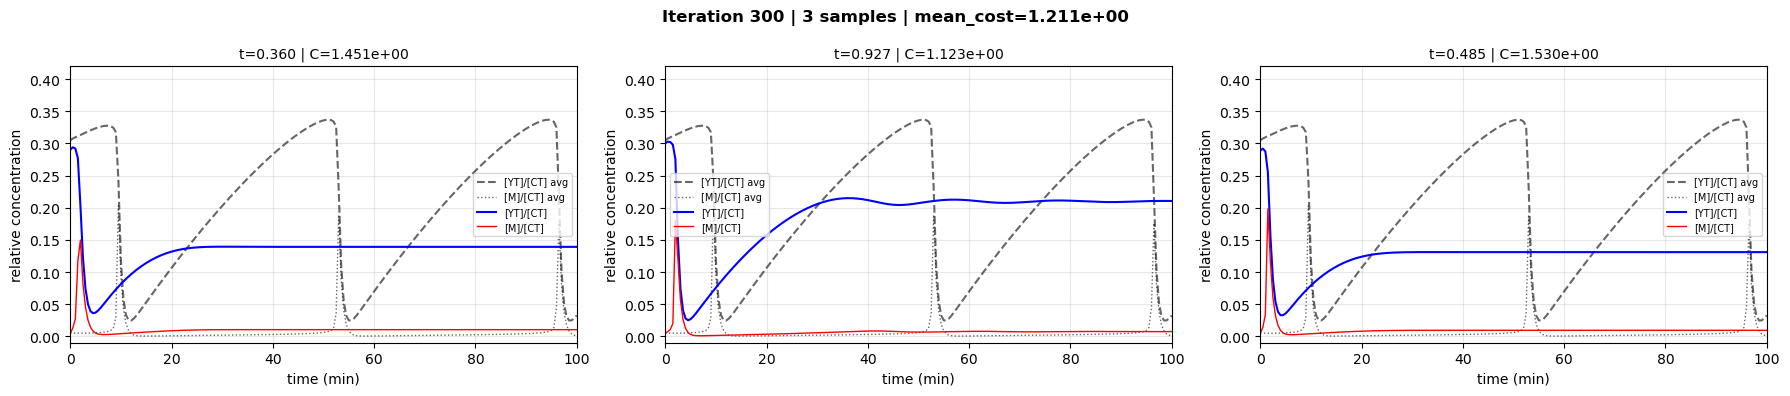

iter 350 | t=[0.889, 0.734, 0.368] | C_avg=1.176e+00 | mean_cost=1.075e+00 | ‖grad‖=2.604e+00 | Δθ=2.604e-03


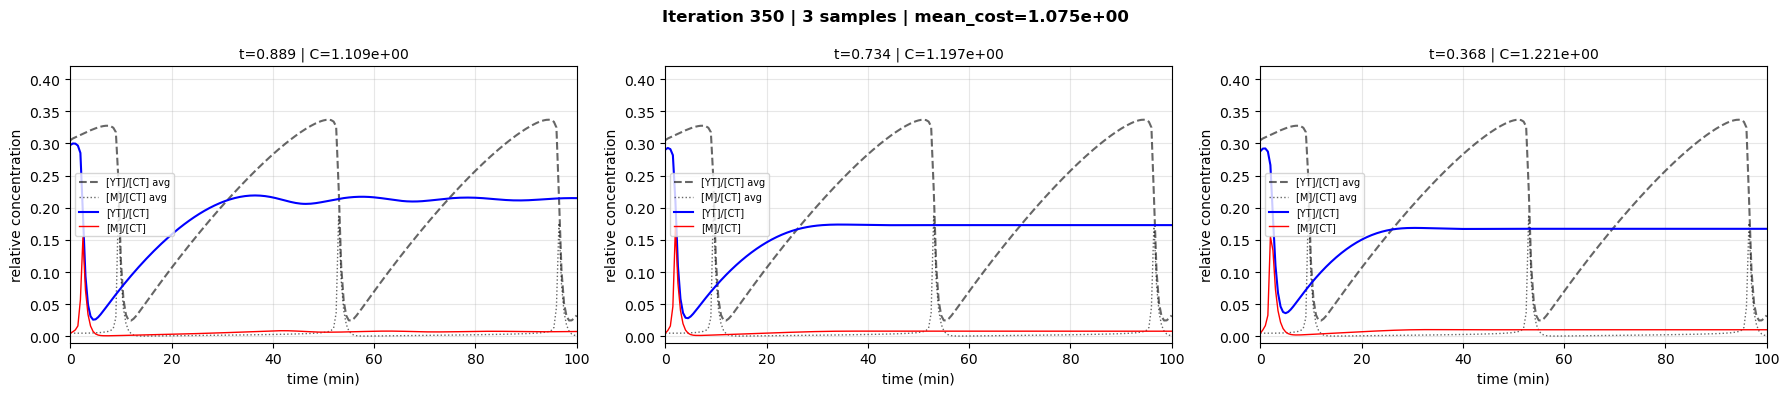

iter 400 | t=[0.601, 0.336, 0.030] | C_avg=1.426e+00 | mean_cost=1.078e+00 | ‖grad‖=3.398e+00 | Δθ=3.398e-03


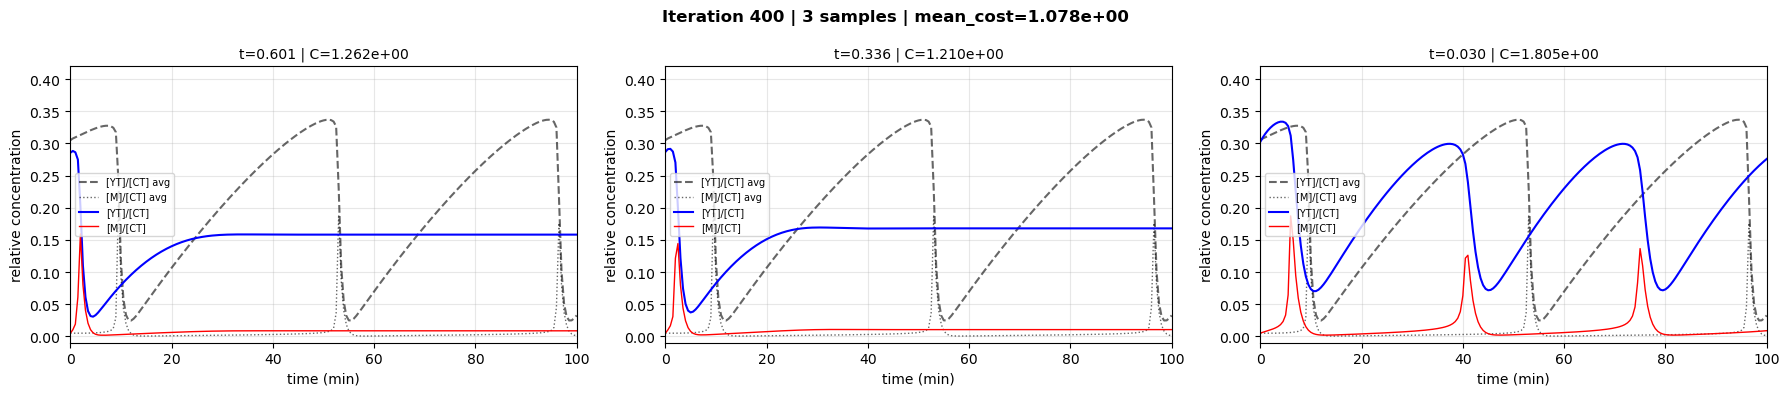

iter 450 | t=[0.424, 0.948, 0.246] | C_avg=1.359e+00 | mean_cost=1.046e+00 | ‖grad‖=3.721e+00 | Δθ=3.721e-03


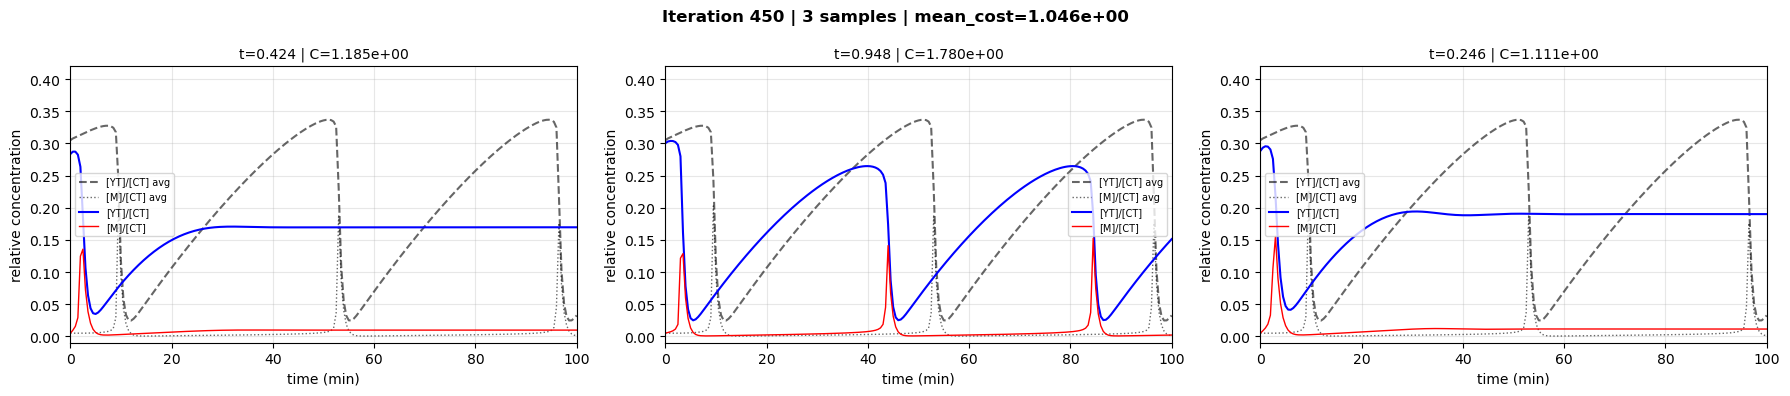

iter 500 | t=[0.580, 0.206, 0.469] | C_avg=1.107e+00 | mean_cost=1.026e+00 | ‖grad‖=2.428e+00 | Δθ=2.428e-03


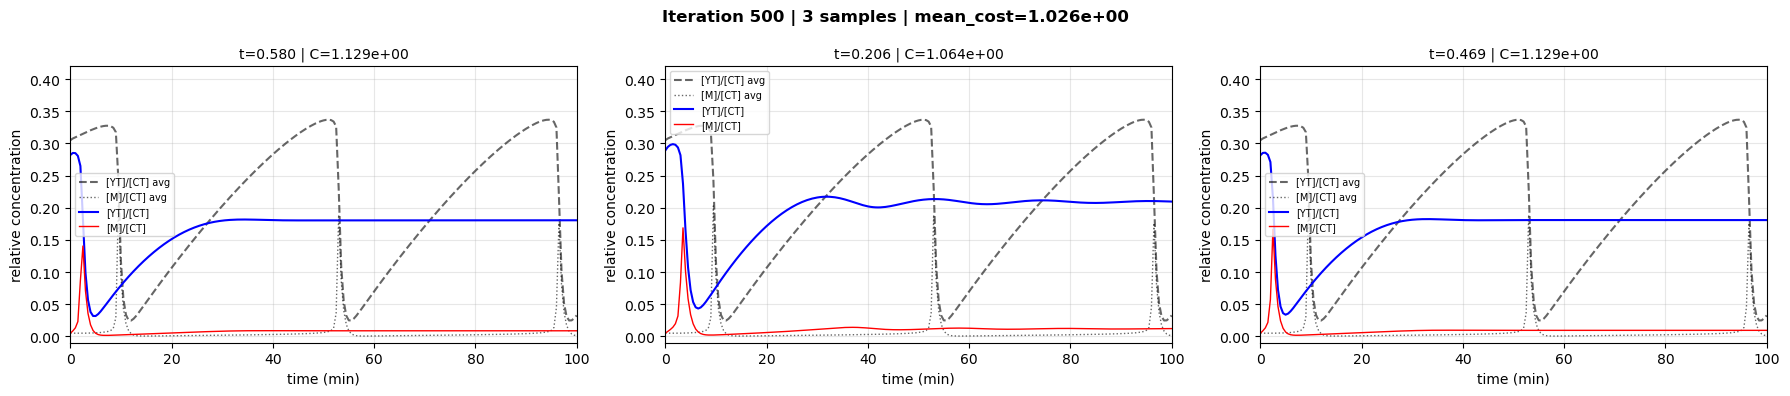

Optimization complete!
Initial cost: 1.671167
Final cost:   1.025854
Change:       -0.645313
Status:       ✓ DECREASING


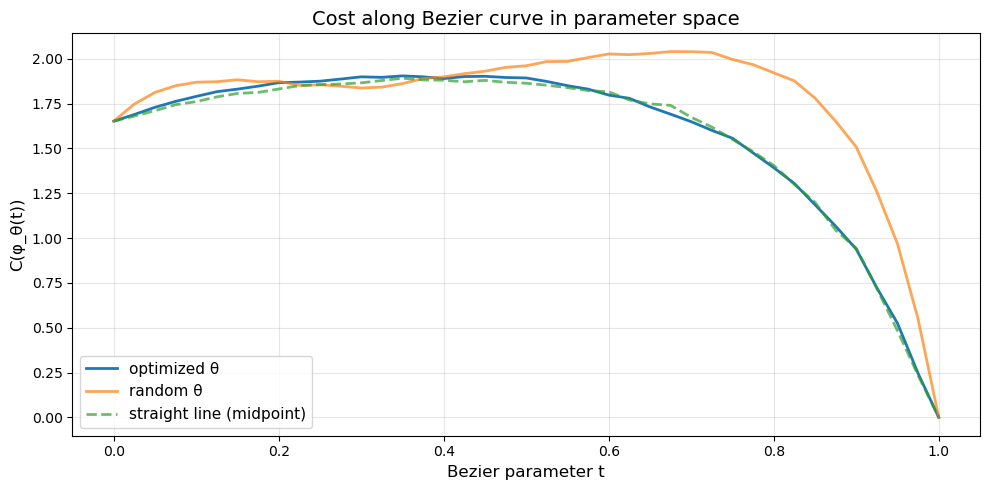

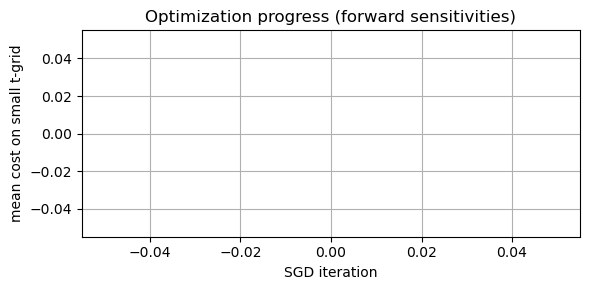

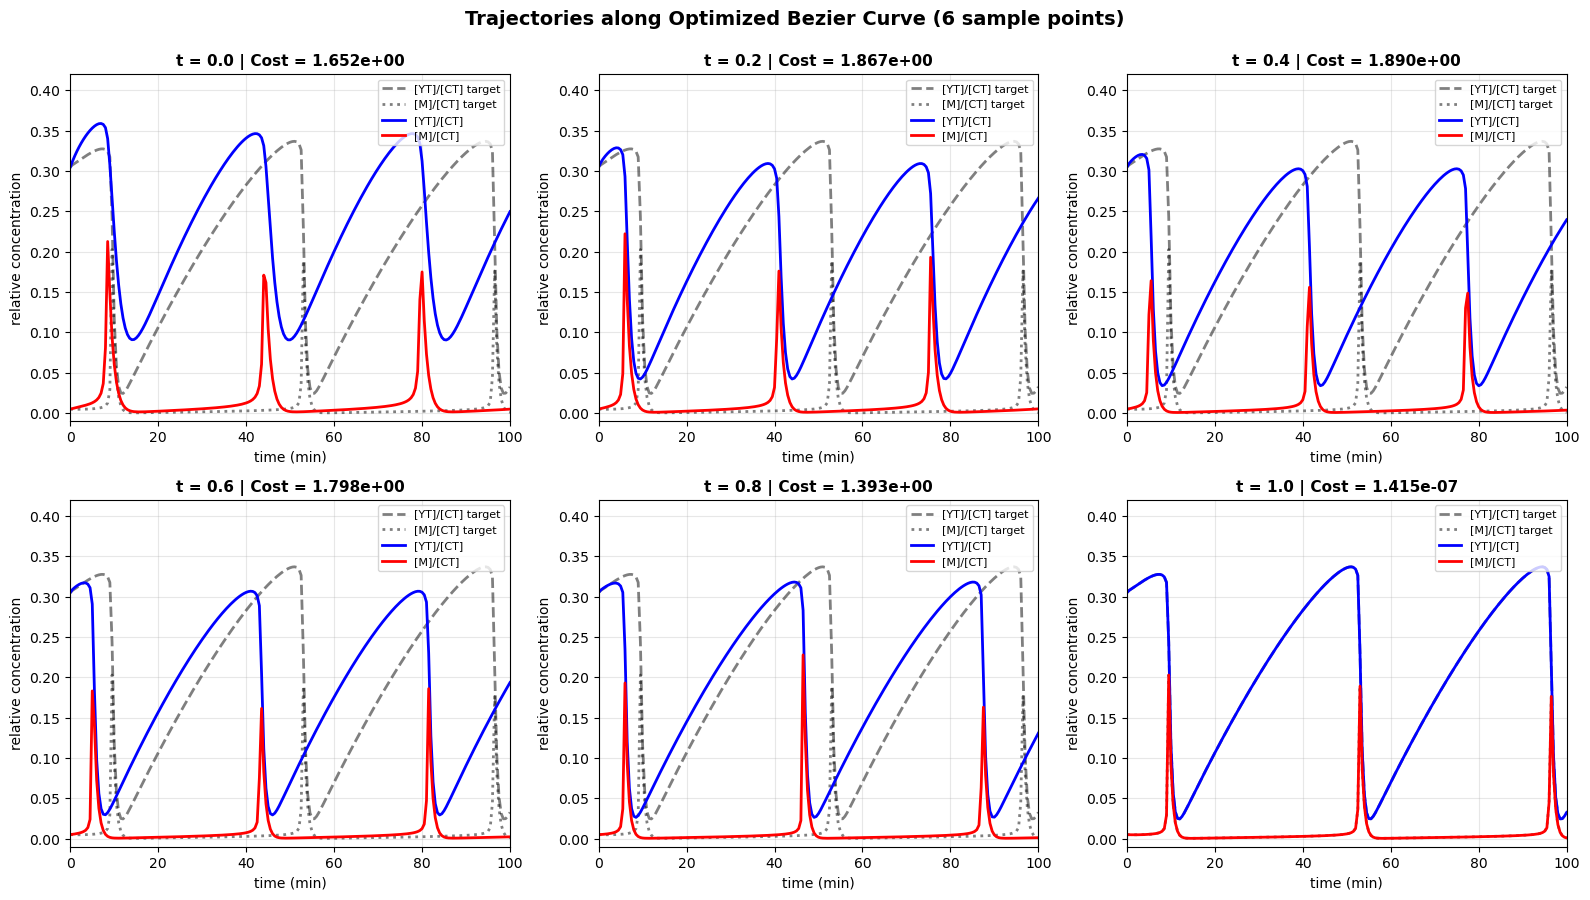


Final optimized theta:
[1.22521702e-02 0.00000000e+00 2.19450052e+02 4.22148085e+02
 1.64315491e-02 0.00000000e+00 1.37193219e+00 5.69364163e+00
 1.00000000e+02 5.00000000e+01 1.00000000e+00]


In [ ]:
# Forward sensitivities for a stiff ODE (BDF) + Bezier control optimization (PyTorch)
# ------------------------------------------------------------------------------
# - Integrates X(t; w) and sensitivities S(t) = dX/dw by solving the augmented ODE:
#       dX/dt = f(X, w)
#       dS/dt = (∂f/∂X) · S + (∂f/∂w)
# - Uses explicit analytical Jacobians Jx and Jw (no nested autograd).
# - Optimizes the quadratic Bezier control point theta with SGD over t ~ U(0,1).
# - Plots cost profiles along t for: optimized theta, random theta, and straight line.
# ------------------------------------------------------------------------------

import math
import numpy as np
try:
    import torch
    from torch import tensor
except ModuleNotFoundError as _err:
    raise ModuleNotFoundError("PyTorch is not installed in this environment.")
from torchdiffeq import odeint
import matplotlib.pyplot as plt

# -------------------------
# Settings (tune as needed)
# -------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.float64
torch.set_default_dtype(dtype)

T_FINAL   = 100.0
N_TSTEPS  = 201               # time grid for integration & trapezoid
RTOL      = 1e-6
ATOL      = 1e-8
EPS_CT    = 1e-12             # to avoid divide-by-zero in CT
SEED      = 0
MAX_ITERS = 50                # SGD iterations on theta
LR        = 1e-3              # learning rate
N_PROFILE = 41                # points for plotting cost vs t
PLOT_EVERY = 50                # plot trajectories every N iterations
NSAMPLE   = 3                 # number of t points to sample per iteration
# Set random seed for reproducibility
torch.manual_seed(SEED)

# -------------------------
# Model (your dynamics)
# -------------------------
def f_torch(state, p_vec):
    # state: tensor length 6  -> [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = state

    k1_aa_over_CT = p_vec[0]
    k2            = p_vec[1]
    k3_CT         = p_vec[2]
    k4            = p_vec[3]
    k4prime       = p_vec[4]
    k5_minusP     = p_vec[5]
    k6            = p_vec[6]
    k7            = p_vec[7]
    k8_minusP     = p_vec[8]
    k9            = p_vec[9]
    CT            = p_vec[10]

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    k1 = k1_aa_over_CT * CT

    # F_M
    FM = k4prime + k4 * (M / denomC)**2

    # rates
    dC2 = k6 * M - k8_minusP * C2 + k9 * CP
    dCP = -k3 * CP * Y + k8_minusP * C2 - k9 * CP
    dpM = k3 * CP * Y - pM * FM + k5_minusP * M
    dM  = pM * FM - k5_minusP * M - k6 * M
    dY  = k1 - k2 * Y - k3 * CP * Y
    dYP = k6 * M - k7 * YP

    return torch.stack([dC2, dCP, dpM, dM, dY, dYP])

# -------------------------
# Analytical Jacobians
# -------------------------
def Jx_f(state, p_vec):
    """Jacobian wrt state: Jx = ∂f/∂X  (6x6)"""
    C2, CP, pM, M, Y, YP = state
    k1_aa_over_CT, k2, k3_CT, k4, k4prime, k5m, k6, k7, k8m, k9, CT = p_vec

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    FM = k4prime + k4 * (M / denomC)**2
    dFM_dM = 2.0 * k4 * M / (denomC**2)

    J = torch.zeros((6,6), dtype=dtype, device=device)

    # dC2
    J[0,0] = -k8m
    J[0,1] =  k9
    J[0,3] =  k6

    # dCP
    J[1,0] =  k8m
    J[1,1] = -k3*Y - k9
    J[1,4] = -k3*CP

    # dpM
    J[2,1] =  k3*Y
    J[2,2] = -FM
    J[2,3] = -pM * dFM_dM + k5m
    J[2,4] =  k3*CP

    # dM
    J[3,2] =  FM
    J[3,3] =  pM * dFM_dM - k5m - k6

    # dY
    J[4,1] = -k3*Y
    J[4,4] = -k2 - k3*CP

    # dYP
    J[5,3] =  k6
    J[5,5] = -k7

    return J

def Jw_f(state, p_vec):
    """Jacobian wrt parameters: Jw = ∂f/∂w  (6x11)"""
    C2, CP, pM, M, Y, YP = state
    k1aa, k2, k3_CT, k4, k4prime, k5m, k6, k7, k8m, k9, CT = p_vec

    denomC = CT + EPS_CT
    k3 = k3_CT / denomC
    FM = k4prime + k4 * (M / denomC)**2

    # helpful partials
    dk3_d_k3CT = 1.0 / denomC
    dk3_d_CT   = -k3_CT / (denomC**2)          # = -k3 / denomC
    dk1_d_k1aa = CT
    dk1_d_CT   = k1aa
    dFM_d_k4   = (M / denomC)**2
    dFM_d_k4p  = 1.0
    dFM_d_CT   = -2.0 * k4 * (M**2) / (denomC**3)

    Jw = torch.zeros((6,11), dtype=dtype, device=device)
    dFM_d_k4p  = 1.0
    # param 0: k1_aa_over_CT
    Jw[4,0] = dk1_d_k1aa                     # only dY
    Jw = torch.zeros((6,11), dtype=dtype, device=device)
    # param 1: k2
    Jw[4,1] = -Y

    # param 2: k3_CT
    Jw[1,2] = -(CP*Y) * dk3_d_k3CT           # dCP
    Jw[2,2] =  (CP*Y) * dk3_d_k3CT           # dpM
    Jw[4,2] = -(CP*Y) * dk3_d_k3CT           # dY

    # param 3: k4 (via FM)
    Jw[2,3] = -pM * dFM_d_k4                 # dpM
    Jw[3,3] =  pM * dFM_d_k4                 # dM

    # param 4: k4prime
    Jw[2,4] = -pM
    Jw[3,4] =  pM

    # param 5: k5_minusP
    Jw[2,5] =  M
    Jw[3,5] = -M

    # param 6: k6
    Jw[0,6] =  M
    Jw[3,6] = -M
    Jw[5,6] =  M
    # param 6: k6
    # param 7: k7
    Jw[5,7] = -YP

    # param 8: k8_minusP
    Jw[0,8] = -C2
    Jw[1,8] =  C2

    # param 9: k9
    Jw[0,9] =  CP
    Jw[1,9] = -CP

    # param 10: CT  (via k1, k3, FM)
    Jw[1,10] = -(CP*Y) * dk3_d_CT
    Jw[2,10] =  (CP*Y) * dk3_d_CT - pM * dFM_d_CT
    Jw[3,10] =  pM * dFM_d_CT
    Jw[4,10] =  dk1_d_CT - (CP*Y) * dk3_d_CT

    return Jw

# -------------------------
# Problem data
# -------------------------
x0 = torch.tensor([0.9, 0.05, 0.0, 0.005, 0.3, 0.0], device=device, dtype=dtype)


1 = torch.tensor([1.5e-02, 0.0, 2.0e+02, 1.8e+02, 1.8e-02, 0.0, 1.0, 0.6, 1.0e+02, 5.0e+01, 1.0],device=device, dtype=dtype)
n_x = x0.numel()
n_w = v1.numel()

ts = torch.linspace(0.0, T_FINAL, N_TSTEPS, device=device, dtype=dtype)

# -------------------------
# Solvers
# -------------------------
def solve_state(w):
    """Return X(t;w) sampled on ts (shape [N_TSTEPS, 6])."""
    with torch.no_grad():
        func = lambda t, y: f_torch(y, w)
        X = odeint(func, x0, ts, method='scipy_solver', options={'solver': 'BDF'}, rtol=RTOL, atol=ATOL)  # [N, 6]
    return X

def solve_state_and_sensitivities(w):
    """Return X(t;w) and S(t)=dX/dw on ts.
       X shape [N,6], S shape [N,6,11]."""
    with torch.no_grad():
        # augmented state: [X, vec(S)]
        y0 = torch.cat([x0, torch.zeros(n_x*n_w, device=device, dtype=dtype)], dim=0)

        def aug_rhs(t, y):
            X = y[:n_x]
            S = y[n_x:].view(n_x, n_w)
            fX = f_torch(X, w)
            Jx = Jx_f(X, w)
            Jw = Jw_f(X, w)
            dS = Jx @ S + Jw
            return torch.cat([fX, dS.reshape(-1)])

        Y = odeint(aug_rhs, y0, ts, method='scipy_solver', options={'solver': 'BDF'}, rtol=RTOL, atol=ATOL)  # [N, 6+6*11]
        X = Y[:, :n_x]
        S = Y[:, n_x:].view(-1, n_x, n_w)
    return X, S

# -------------------------
# Cost and gradient wrt w
# -------------------------
def trajectory_cost_and_grad_w(w, Xavg):
    """C(w) = ∫ 0.5||X(t;w)-Xavg(t)||^2 dt;  dC/dw = ∫ (X-Xavg)^T S dt."""
    with torch.no_grad():
        X, S = solve_state_and_sensitivities(w)           # [N,6], [N,6,11]
        diff = X - Xavg                                   # [N,6]
        integrand = 0.5 * (diff**2).sum(dim=1)            # [N]
        C = torch.trapz(integrand, ts)

        # (X-Xavg)^T @ S -> [N, 11]
        # diff[k]: [6], S[k]: [6,11]
        integrand_g = torch.einsum('ni, nij -> nj', diff, S)
        dC_dw = torch.trapz(integrand_g, ts, dim=0)       # [11]
    return C, dC_dw

# -------------------------
# Bezier helpers
# -------------------------
def phi_theta(theta, t_scalar):
    t = torch.as_tensor(t_scalar, dtype=dtype, device=device)
    return (1.0 - t)**2 * v1 + 2.0*t*(1.0 - t)*theta + t**2 * v2

def dphi_dtheta_scalar(t_scalar):
    t = torch.as_tensor(t_scalar, dtype=dtype, device=device)
    return 2.0 * t * (1.0 - t)                        # scalar multiplier on I

# -------------------------
# Helper function to compute YT_rel and M_rel from trajectory
# -------------------------
def compute_tyson_observables(X, CT):
    """Given trajectory X [N,6] and CT value, return YT_rel and M_rel."""
    # X columns: [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = X[:, 0], X[:, 1], X[:, 2], X[:, 3], X[:, 4], X[:, 5]
    YT = Y + YP + pM + M
    YT_rel = YT / (CT + EPS_CT)
    M_rel = M / (CT + EPS_CT)
    return YT_rel, M_rel

# -------------------------
# Prepare target (Xavg from v1, v2)
# -------------------------
with torch.no_grad():
    X1 = solve_state(v1)        # [N,6]
    X2 = solve_state(v2)        # [N,6]
    WEIGHT = 1
    Xavg = (1-WEIGHT)*X1 + WEIGHT*X2 
         # [N,6]
    
    # Compute baseline observables for plotting
    CT_avg = (1-WEIGHT)*v1[10] + WEIGHT*v2[10]
    YT_avg, M_avg = compute_tyson_observables(Xavg, CT_avg)

# -------------------------
# Optimize theta (SGD on forward-sensitivity gradient)
# -------------------------
torch.manual_seed(SEED)
theta_mid = 0.5 * (v1 + v2)
# initialize theta on device and enforce non-negativity
theta     = (theta_mid + 0.2 * (v2 - v1) * torch.randn_like(v1)).clone().to(device)
theta = theta.clamp(min=0.0)

history = []
# FIXED OPTIMIZATION with diagnostics
# -------------------------
torch.manual_seed(SEED)
theta_mid = 0.5 * (v1 + v2)
theta_new = (theta_mid + 0.2 * (v2 - v1) * torch.randn_like(v1)).clone().to(device)
theta_new = theta_new.clamp(min=0.0)
MAX_ITERS=500

history_fixed = []
t_samples = []  # Track sampled t values (will store NSAMPLE values per iteration)
grad_norms = []  # Track gradient magnitudes
theta_changes = []  # Track parameter updates

print("Starting FIXED optimization with NSAMPLE={} samples per iteration...".format(NSAMPLE))
print("="*70)

for it in range(1, MAX_ITERS+1):
    # Sample NSAMPLE points along the curve
    t_samps = [torch.rand(()).item() for _ in range(NSAMPLE)]
    
    # Accumulate gradients from all samples
    dL_dtheta_accumulated = torch.zeros_like(theta_new)
    C_samps = []
    w_samps = []
    
    for t_samp in t_samps:
        # Compute parameter vector (no grad tracking needed)
        with torch.no_grad():
            w_samp = phi_theta(theta_new, t_samp)
        w_samps.append(w_samp)
        
        # Forward sensitivities for dC/dw (already wrapped in no_grad inside function)
        C_samp, dC_dw = trajectory_cost_and_grad_w(w_samp, Xavg)
        C_samps.append(C_samp.item())
        
        # Chain rule: dL/dtheta = dC/dw * dphi/dtheta
        with torch.no_grad():
            mult = dphi_dtheta_scalar(t_samp)
            dL_dtheta = dC_dw * mult
            
            # Accumulate gradient
            dL_dtheta_accumulated += dL_dtheta
    
    # Average the accumulated gradient
    dL_dtheta_avg = dL_dtheta_accumulated / NSAMPLE
    
    # Track diagnostics BEFORE update
    grad_norm = dL_dtheta_avg.norm().item()
    grad_norms.append(grad_norm)
    t_samples.extend(t_samps)  # Store all sampled t values
    
    # Gradient step (apply update and then clamp to enforce theta >= 0)
    with torch.no_grad():
        theta_old = theta_new.clone()
        theta_new -= LR * dL_dtheta_avg
        theta_new.clamp_(min=0.0)
        param_change = (theta_new - theta_old).norm().item()
        theta_changes.append(param_change)
    
    # Track mean cost on a small grid for monitoring
    with torch.no_grad():
        t_eval = torch.linspace(0, 1, 7, device=device, dtype=dtype)
        costs = []
        for tt in t_eval:
            Ctt, _ = trajectory_cost_and_grad_w(phi_theta(theta_new, float(tt)), Xavg)
            costs.append(Ctt.item())
        mean_cost = float(np.mean(costs))
        history_fixed.append(mean_cost)
        
        # Print every PLOT_EVERY iterations
        if it % PLOT_EVERY == 0 or it == 1:
            avg_C = np.mean(C_samps)
            t_str = ', '.join([f'{t:.3f}' for t in t_samps])
            print(f"iter {it:03d} | t=[{t_str}] | C_avg={avg_C:.3e} | "
                  f"mean_cost={mean_cost:.3e} | ‖grad‖={grad_norm:.3e} | Δθ={param_change:.3e}")
        
        # Quick visual check every PLOT_EVERY - plot all NSAMPLE samples in subplots
        if it % PLOT_EVERY == 0 or it == 1:
            fig, axes = plt.subplots(1, NSAMPLE, figsize=(6*NSAMPLE, 4))
            if NSAMPLE == 1:
                axes = [axes]  # Make it iterable
            
            t_np = ts.cpu().numpy()
            
            for idx, (t_samp, w_samp, C_samp) in enumerate(zip(t_samps, w_samps, C_samps)):
                with torch.no_grad():
                    X_samp = solve_state(w_samp)
                    CT_samp = w_samp[10].item()
                    YT_samp, M_samp = compute_tyson_observables(X_samp, CT_samp)
                
                ax = axes[idx]
                ax.plot(t_np, YT_avg.cpu().numpy(), 'k--', lw=1.5, alpha=0.6, label='[YT]/[CT] avg')
                ax.plot(t_np, M_avg.cpu().numpy(), 'k:', lw=1.0, alpha=0.6, label='[M]/[CT] avg')
                ax.plot(t_np, YT_samp.cpu().numpy(), 'b-', lw=1.5, label='[YT]/[CT]')
                ax.plot(t_np, M_samp.cpu().numpy(), 'r-', lw=1.0, label='[M]/[CT]')
                ax.set_xlim(0, 100)
                ax.set_ylim(-0.01, 0.42)
                ax.set_xlabel('time (min)', fontsize=10)
                ax.set_ylabel('relative concentration', fontsize=10)
                ax.set_title(f't={t_samp:.3f} | C={C_samp:.3e}', fontsize=10)
                ax.legend(fontsize=7)
                ax.grid(True, alpha=0.3)
            
            plt.suptitle(f'Iteration {it} | {NSAMPLE} samples | mean_cost={mean_cost:.3e}', 
                        fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

print("="*70)
print("Optimization complete!")
print(f"Initial cost: {history_fixed[0]:.6f}")
print(f"Final cost:   {history_fixed[-1]:.6f}")
print(f"Change:       {history_fixed[-1] - history_fixed[0]:+.6f}")
print(f"Status:       {'✓ DECREASING' if history_fixed[-1] < history_fixed[0] else '❌ INCREASING'}")

# -------------------------
# Compare cost profiles along t
# -------------------------
def cost_along_curve(theta_ctrl, t_grid):
    vals = []
    with torch.no_grad():
        for tt in t_grid:
            w_tt = phi_theta(theta_ctrl, float(tt))
            Ctt, _ = trajectory_cost_and_grad_w(w_tt, Xavg)
            vals.append(Ctt.item())
    return np.array(vals)

t_plot = np.linspace(0.0, 1.0, N_PROFILE)
theta_opt  = theta.detach().clone()
torch.manual_seed(SEED + 1)  # Different seed for random comparison
theta_rand = (theta_mid + 0.2 * (v2 - v1) * torch.randn_like(v1)).clone().to(device)
theta_rand = theta_rand.clamp(min=0.0)
theta_line = theta_mid.clone().to(device)
theta_line = theta_line.clamp(min=0.0)

cost_opt  = cost_along_curve(theta_opt,  t_plot)
cost_rand = cost_along_curve(theta_rand, t_plot)
cost_line = cost_along_curve(theta_line, t_plot)

# -------------------------
# Plots
# -------------------------
# Plot 1: Cost comparison along Bezier curves
plt.figure(figsize=(10,5))
plt.plot(t_plot, cost_opt,  label='optimized θ', linewidth=2)
plt.plot(t_plot, cost_rand, label='random θ', linewidth=2, alpha=0.7)
plt.plot(t_plot, cost_line, label='straight line (midpoint)', linewidth=2, alpha=0.7, linestyle='--')
plt.xlabel('Bezier parameter t', fontsize=12)
plt.ylabel('C(φ_θ(t))', fontsize=12)
plt.title('Cost along Bezier curve in parameter space', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Plot 2: Optimization progress
plt.figure(figsize=(6,3))
plt.plot(np.arange(1, len(history)+1), history, '-o', markersize=3)
plt.xlabel('SGD iteration')
plt.ylabel('mean cost on small t-grid')
plt.title('Optimization progress (forward sensitivities)')
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# Plot 3: Trajectories at 6 t values on optimized Bezier curve
# -------------------------
t_samples_plot = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

with torch.no_grad():
    for idx, t_val in enumerate(t_samples_plot):
        # Get parameter vector at this t
        w_t = phi_theta(theta_opt, t_val)
        
        # Solve ODE for this parameter set
        X_t = solve_state(w_t)
        CT_t = w_t[10].item()
        YT_t, M_t = compute_tyson_observables(X_t, CT_t)
        
        # Compute cost at this point
        C_t, _ = trajectory_cost_and_grad_w(w_t, Xavg)
        
        # Plot in subplot
        ax = axes[idx]
        t_np = ts.cpu().numpy()
        
        # Baseline (target)
        ax.plot(t_np, YT_avg.cpu().numpy(), 'k--', lw=2, alpha=0.5, label='[YT]/[CT] target')
        ax.plot(t_np, M_avg.cpu().numpy(), 'k:', lw=2, alpha=0.5, label='[M]/[CT] target')
        
        # Current trajectory
        ax.plot(t_np, YT_t.cpu().numpy(), 'b-', lw=2, label='[YT]/[CT]')
        ax.plot(t_np, M_t.cpu().numpy(), 'r-', lw=2, label='[M]/[CT]')
        
        ax.set_xlim(0, 100)
        ax.set_ylim(-0.01, 0.42)
        ax.set_xlabel('time (min)', fontsize=10)
        ax.set_ylabel('relative concentration', fontsize=10)
        ax.set_title(f't = {t_val:.1f} | Cost = {C_t.item():.3e}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)

plt.suptitle('Trajectories along Optimized Bezier Curve (6 sample points)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print final theta
print("\n" + "="*70)
print("Final optimized theta:")
print("="*70)
print(theta_opt.cpu().numpy())
print("="*70)y

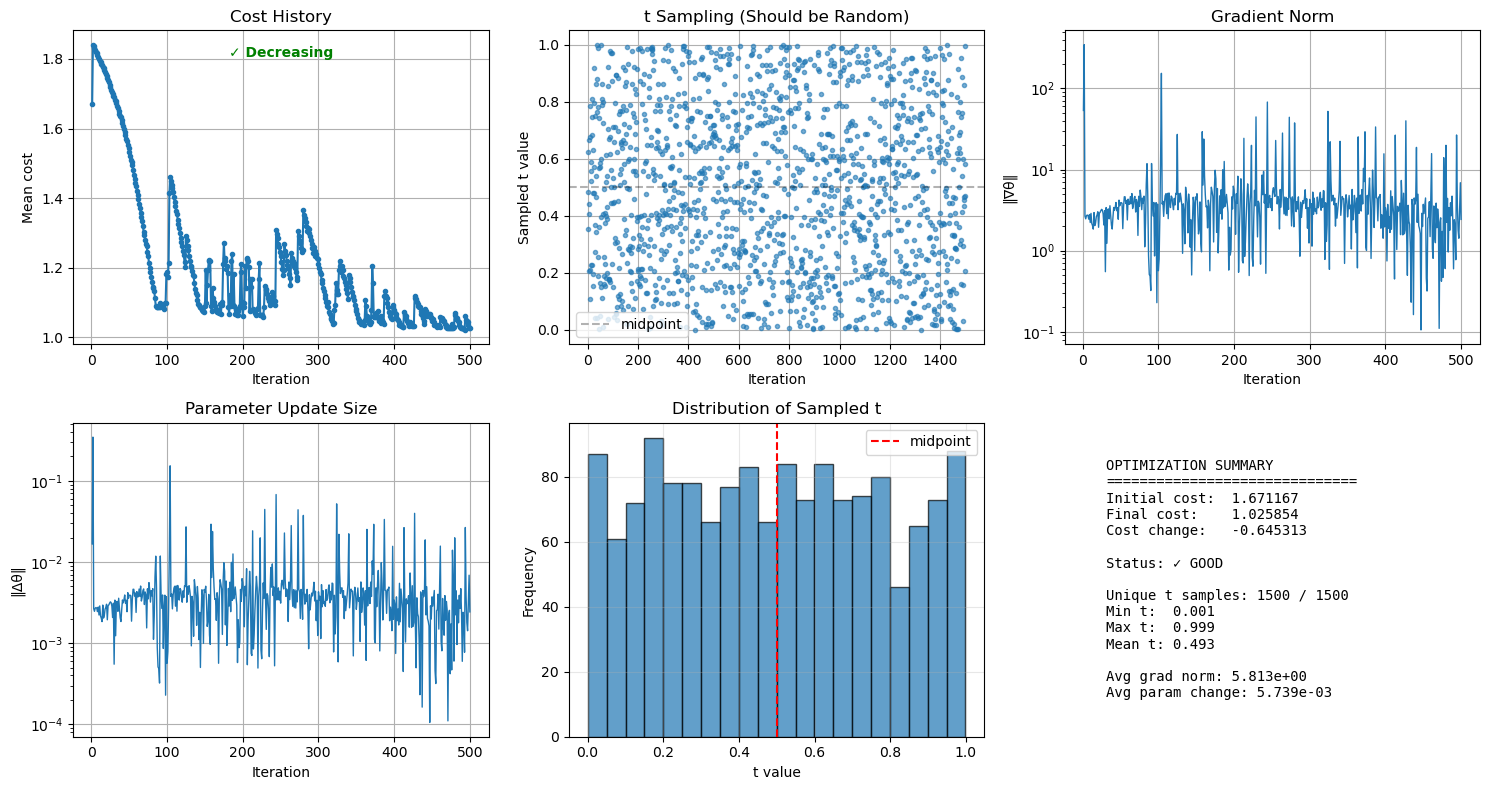

In [4]:
# Diagnostic plots for the fixed optimization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1. Cost history
axes[0,0].plot(np.arange(1, len(history_fixed)+1), history_fixed, '-o', markersize=3)
axes[0,0].set_xlabel('Iteration')
axes[0,0].set_ylabel('Mean cost')
axes[0,0].set_title('Cost History')
axes[0,0].grid(True)
if history_fixed[-1] < history_fixed[0]:
    axes[0,0].text(0.5, 0.95, '✓ Decreasing', transform=axes[0,0].transAxes, 
                   ha='center', va='top', color='green', weight='bold')
else:
    axes[0,0].text(0.5, 0.95, '❌ Increasing', transform=axes[0,0].transAxes, 
                   ha='center', va='top', color='red', weight='bold')

# 2. Sampled t values (should be diverse)
axes[0,1].plot(np.arange(1, len(t_samples)+1), t_samples, 'o', markersize=3, alpha=0.6)
axes[0,1].axhline(0.5, color='k', linestyle='--', alpha=0.3, label='midpoint')
axes[0,1].set_xlabel('Iteration')
axes[0,1].set_ylabel('Sampled t value')
axes[0,1].set_title('t Sampling (Should be Random)')
axes[0,1].set_ylim(-0.05, 1.05)
axes[0,1].grid(True)
axes[0,1].legend()

# 3. Gradient norms
axes[0,2].plot(np.arange(1, len(grad_norms)+1), grad_norms, '-', linewidth=1)
axes[0,2].set_xlabel('Iteration')
axes[0,2].set_ylabel('‖∇θ‖')
axes[0,2].set_title('Gradient Norm')
axes[0,2].set_yscale('log')
axes[0,2].grid(True)

# 4. Parameter changes
axes[1,0].plot(np.arange(1, len(theta_changes)+1), theta_changes, '-', linewidth=1)
axes[1,0].set_xlabel('Iteration')
axes[1,0].set_ylabel('‖Δθ‖')
axes[1,0].set_title('Parameter Update Size')
axes[1,0].set_yscale('log')
axes[1,0].grid(True)

# 5. Histogram of t samples
axes[1,1].hist(t_samples, bins=20, alpha=0.7, edgecolor='black')
axes[1,1].axvline(0.5, color='r', linestyle='--', label='midpoint')
axes[1,1].set_xlabel('t value')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Sampled t')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# 6. Summary stats
axes[1,2].axis('off')
summary_text = f"""
OPTIMIZATION SUMMARY
{'='*30}
Initial cost:  {history_fixed[0]:.6f}
Final cost:    {history_fixed[-1]:.6f}
Cost change:   {history_fixed[-1] - history_fixed[0]:+.6f}

Status: {'✓ GOOD' if history_fixed[-1] < history_fixed[0] else '❌ BAD'}

Unique t samples: {len(set(t_samples))} / {len(t_samples)}
Min t:  {min(t_samples):.3f}
Max t:  {max(t_samples):.3f}
Mean t: {np.mean(t_samples):.3f}

Avg grad norm: {np.mean(grad_norms):.3e}
Avg param change: {np.mean(theta_changes):.3e}
"""
axes[1,2].text(0.1, 0.5, summary_text, transform=axes[1,2].transAxes, 
               fontfamily='monospace', fontsize=10, verticalalignment='center')

plt.tight_layout()
plt.show()

Computing 2D cost landscape on the Bézier plane...
This may take a few minutes (computing cost at 900 grid points)...
Plane basis vector u (v1→θ) norm: 2.430e+02
Plane basis vector v (v1→v2) norm: 4.974e+02
Computing cost on 30x30 = 900 grid points...
  Progress: 5/30 rows computed...
  Progress: 10/30 rows computed...
  Progress: 15/30 rows computed...
  Progress: 20/30 rows computed...
  Progress: 25/30 rows computed...
  Progress: 30/30 rows computed...
Grid computation complete! Generating plots...


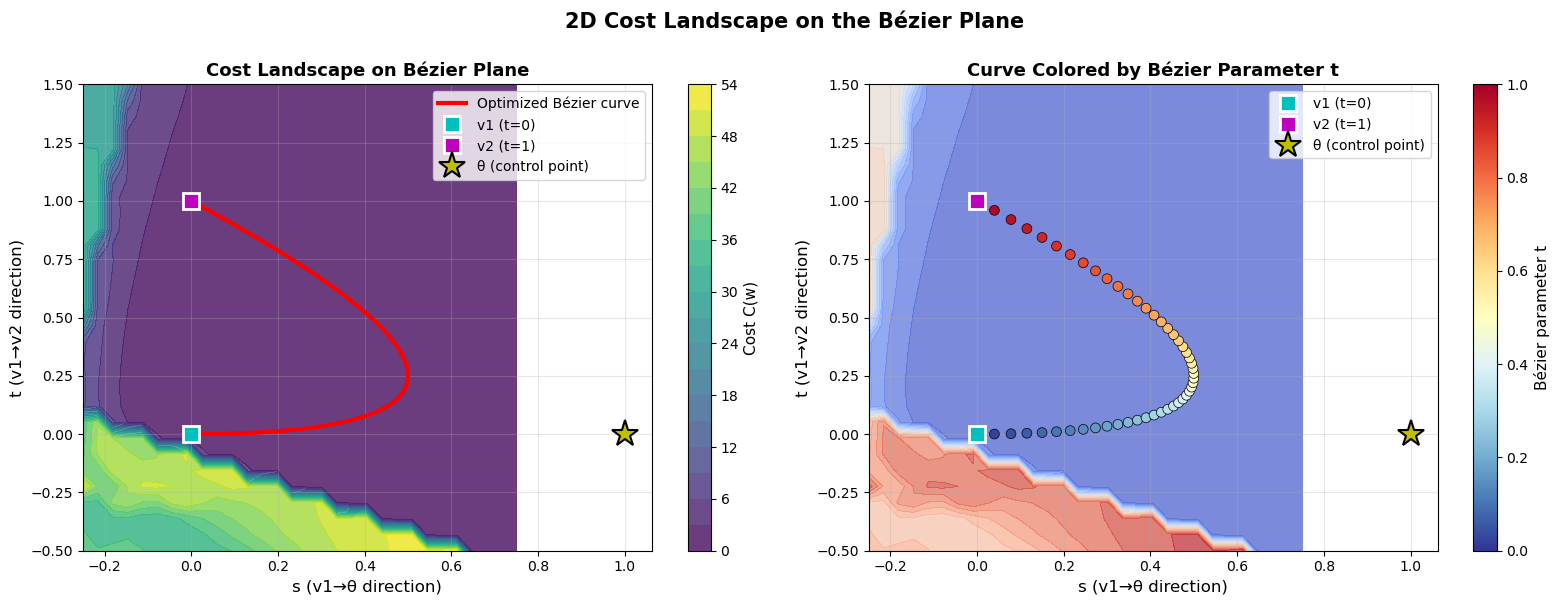

Done!


In [8]:
# 2D Cost Contour Plot with Bezier Curve Overlay
# -------------------------------------------------------------------------
# Visualize the cost landscape ON THE BEZIER PLANE
# The Bezier curve lies in a 2D plane defined by v1, theta, and v2
# -------------------------------------------------------------------------

print("Computing 2D cost landscape on the Bézier plane...")
print("This may take a few minutes (computing cost at 900 grid points)...")

# The Bezier plane is spanned by two vectors:
# - Direction from v1 to theta
# - Direction from v1 to v2
with torch.no_grad():
    # Basis vectors for the plane
    u = (theta_new - v1).cpu().numpy()  # v1 -> theta
    v = (v2 - v1).cpu().numpy()          # v1 -> v2
    
    # Origin of the plane
    origin = v1.cpu().numpy()
    
    # Normalize basis vectors for easier interpretation
    u_norm = np.linalg.norm(u)
    v_norm = np.linalg.norm(v)
    
    print(f"Plane basis vector u (v1→θ) norm: {u_norm:.3e}")
    print(f"Plane basis vector v (v1→v2) norm: {v_norm:.3e}")

# Sample the Bezier curve in the parametric (s,t) space
n_curve_pts = 50
t_curve = np.linspace(0, 1, n_curve_pts)
curve_st = []  # Store (s,t) coordinates of curve points

for t_val in t_curve:
    # Bezier curve: (1-t)²v1 + 2t(1-t)θ + t²v2
    # Rewrite in terms of plane coordinates (s,t):
    # Point on curve = v1 + s*u + t*v
    # 
    # Bezier point = v1 + [2t(1-t)]*(θ-v1) + [t²]*(v2-v1)
    #              = v1 + [2t(1-t)]*u + [t²]*v
    # So: s = 2t(1-t), t_coord = t²
    
    s_coord = 2 * t_val * (1 - t_val)
    t_coord = t_val**2
    curve_st.append([s_coord, t_coord])

curve_st = np.array(curve_st)

# Define grid bounds in (s,t) space
# Extend beyond the curve range
s_min, s_max = curve_st[:, 0].min(), curve_st[:, 0].max()
t_min, t_max = curve_st[:, 1].min(), curve_st[:, 1].max()
s_range = s_max - s_min
t_range = t_max - t_min

# Extend by 50% on each side
s_min -= 0.5 * s_range
s_max += 0.5 * s_range
t_min -= 0.5 * t_range
t_max += 0.5 * t_range

# Create 2D grid in plane coordinates
n_grid = 30
s_grid = np.linspace(s_min, s_max, n_grid)
t_grid = np.linspace(t_min, t_max, n_grid)
S_mesh, T_mesh = np.meshgrid(s_grid, t_grid)

# Compute cost at each grid point
print(f"Computing cost on {n_grid}x{n_grid} = {n_grid**2} grid points...")
C_grid = np.zeros((n_grid, n_grid))

with torch.no_grad():
    for i in range(n_grid):
        for j in range(n_grid):
            # Convert (s,t) plane coordinates to 11D parameter space
            # w = v1 + s*u + t*v
            s_val = S_mesh[i, j]
            t_val = T_mesh[i, j]
            
            w_grid = torch.tensor(origin + s_val * u + t_val * v, 
                                 dtype=dtype, device=device)
            
            # Clamp to non-negative (important for physical parameters)
            w_grid = w_grid.clamp(min=0.0)
            
            # Compute cost
            C_val, _ = trajectory_cost_and_grad_w(w_grid, Xavg)
            C_grid[i, j] = C_val.item()
        
        if (i + 1) % 5 == 0:
            print(f"  Progress: {i+1}/{n_grid} rows computed...")

print("Grid computation complete! Generating plots...")

# Also compute positions of v1, theta, v2 in (s,t) coordinates
v1_st = [0.0, 0.0]  # v1 is the origin
theta_st = [1.0, 0.0]  # theta = v1 + 1*u + 0*v
v2_st = [0.0, 1.0]  # v2 = v1 + 0*u + 1*v

# -------------------------
# Create side-by-side plots
# -------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Contour with curve overlay
contour1 = ax1.contourf(S_mesh, T_mesh, C_grid, levels=20, cmap='viridis', alpha=0.8)
ax1.plot(curve_st[:, 0], curve_st[:, 1], 'r-', linewidth=3, label='Optimized Bézier curve')
ax1.plot(v1_st[0], v1_st[1], 'cs', markersize=12, 
         markeredgecolor='white', markeredgewidth=2, label='v1 (t=0)')
ax1.plot(v2_st[0], v2_st[1], 'ms', markersize=12,
         markeredgecolor='white', markeredgewidth=2, label='v2 (t=1)')
ax1.plot(theta_st[0], theta_st[1], 'y*', 
         markersize=20, markeredgecolor='black', markeredgewidth=1.5, label='θ (control point)')
ax1.set_xlabel('s (v1→θ direction)', fontsize=12)
ax1.set_ylabel('t (v1→v2 direction)', fontsize=12)
ax1.set_title('Cost Landscape on Bézier Plane', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(contour1, ax=ax1)
cbar1.set_label('Cost C(w)', fontsize=11)

# Right plot: Same but with curve colored by Bezier parameter
contour2 = ax2.contourf(S_mesh, T_mesh, C_grid, levels=20, cmap='coolwarm', alpha=0.7)
t_bezier = np.linspace(0, 1, n_curve_pts)
scatter = ax2.scatter(curve_st[:, 0], curve_st[:, 1], c=t_bezier, cmap='RdYlBu_r', 
                     s=50, edgecolor='black', linewidth=0.5, zorder=5)
ax2.plot(v1_st[0], v1_st[1], 'cs', markersize=12,
         markeredgecolor='white', markeredgewidth=2, label='v1 (t=0)', zorder=6)
ax2.plot(v2_st[0], v2_st[1], 'ms', markersize=12,
         markeredgecolor='white', markeredgewidth=2, label='v2 (t=1)', zorder=6)
ax2.plot(theta_st[0], theta_st[1], 'y*',
         markersize=20, markeredgecolor='black', markeredgewidth=1.5, 
         label='θ (control point)', zorder=6)
ax2.set_xlabel('s (v1→θ direction)', fontsize=12)
ax2.set_ylabel('t (v1→v2 direction)', fontsize=12)
ax2.set_title('Curve Colored by Bézier Parameter t', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter, ax=ax2)
cbar2.set_label('Bézier parameter t', fontsize=11)

plt.suptitle('2D Cost Landscape on the Bézier Plane', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("Done!")

Grid computed: shape=(60, 60), NaNs=9, min=5.878e-03, mean=1.501e+00, max=2.315e+01
Cells where any parameter would be negative (pre-clamp): 9


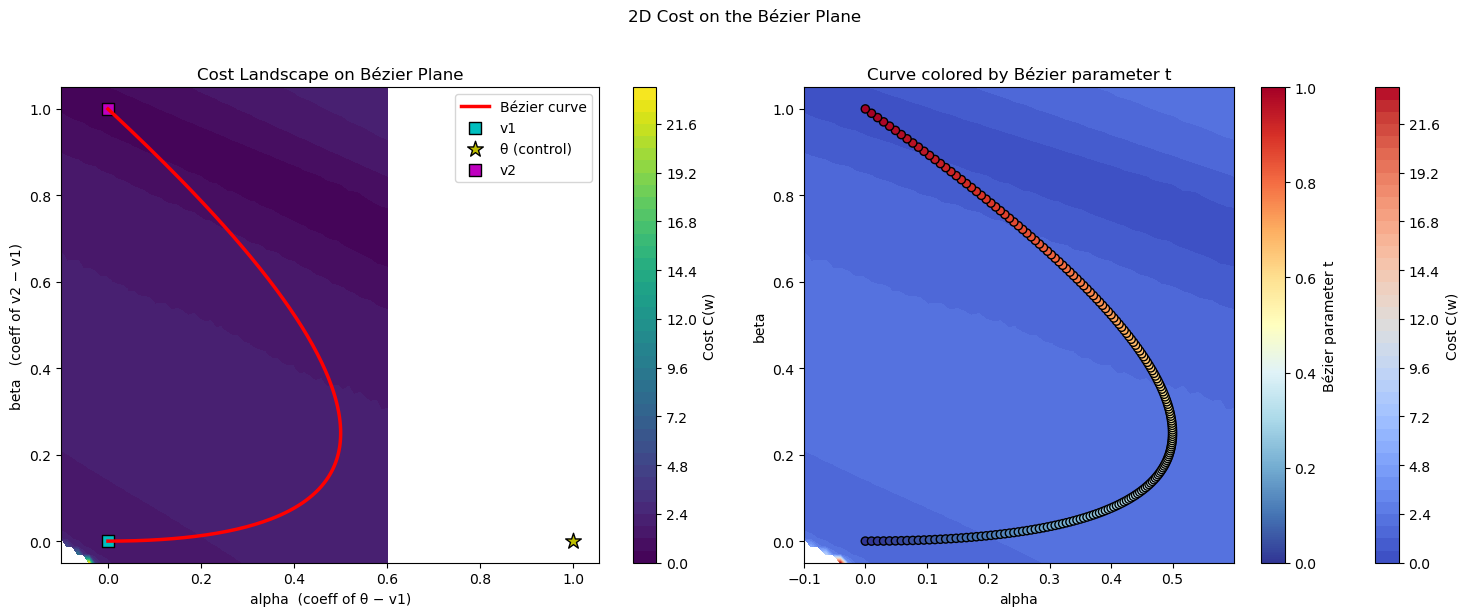

In [9]:
# === 2D cost on the Bézier plane (drop-in cell) ===
# Assumes you already have: v1, v2, Xavg, trajectory_cost_and_grad_w(...)
# And a control point: one of {theta, theta_new, theta_opt}. We'll auto-pick.

import numpy as np
import torch
import matplotlib.pyplot as plt

# --- pick the control point you have in scope ---
theta_ctrl = None
for name in ("theta", "theta_new", "theta_opt", "theta_mid"):
    if name in globals():
        theta_ctrl = globals()[name]
        break
assert theta_ctrl is not None, "No control point found (theta/theta_new/theta_opt/theta_mid)."

# --- device/dtype from v1 to avoid mismatches ---
_device = v1.device
_dtype  = v1.dtype

# --- plane basis: w = v1 + alpha*(theta - v1) + beta*(v2 - v1) ---
u = (theta_ctrl - v1).detach().cpu().numpy()
v = (v2 - v1).detach().cpu().numpy()
origin = v1.detach().cpu().numpy()

# Bézier curve in plane coords: (alpha,beta) = (2t(1-t), t^2)
n_curve_pts = 200
t_curve = np.linspace(0.0, 1.0, n_curve_pts)
alpha_curve = 2.0 * t_curve * (1.0 - t_curve)          # in [0, 0.5]
beta_curve  = t_curve ** 2                              # in [0, 1]

# --- grid around the curve domain (tight pad so plots are informative) ---
pad_alpha = 0.10
pad_beta  = 0.05
alpha_min, alpha_max = alpha_curve.min() - pad_alpha, alpha_curve.max() + pad_alpha
beta_min,  beta_max  = beta_curve.min()  - pad_beta,  beta_curve.max()  + pad_beta

n_grid = 60
alpha_vals = np.linspace(alpha_min, alpha_max, n_grid)
beta_vals  = np.linspace(beta_min,  beta_max,  n_grid)
ALPHA, BETA = np.meshgrid(alpha_vals, beta_vals)

# settings
skip_invalid = True   # if True: leave cells with any negative parameter as NaN (blank on plot)
                      # if False: clamp negatives to zero before cost (shows clamped regions)
C_grid = np.full_like(ALPHA, np.nan, dtype=float)
clamped_mask = np.zeros_like(ALPHA, dtype=bool)

# --- compute cost on grid (no autograd) ---
with torch.no_grad():
    for ii, beta in enumerate(beta_vals):       # row (vertical axis)
        for jj, alpha in enumerate(alpha_vals): # col (horizontal axis)
            w_vec = origin + alpha * u + beta * v
            neg = (w_vec < 0.0)
            if neg.any():
                clamped_mask[ii, jj] = True
                if skip_invalid:
                    continue
                w_vec = np.maximum(w_vec, 0.0)

            w = torch.tensor(w_vec, dtype=_dtype, device=_device)
            C_val, _ = trajectory_cost_and_grad_w(w, Xavg)
            C_grid[ii, jj] = float(C_val)

# --- quick diagnostics ---
n_nan = int(np.isnan(C_grid).sum())
finite = np.isfinite(C_grid)
print(f"Grid computed: shape={C_grid.shape}, NaNs={n_nan}, "
      f"min={np.nanmin(C_grid):.3e}, mean={np.nanmean(C_grid):.3e}, max={np.nanmax(C_grid):.3e}")
print(f"Cells where any parameter would be negative (pre-clamp): {int(clamped_mask.sum())}")

# --- plotting ---
masked_C = np.ma.masked_invalid(C_grid)

fig, axs = plt.subplots(1, 2, figsize=(15, 6))

# Left: cost with curve overlay, invalid shown as blank; clamped region hatched if skip_invalid=False
cs1 = axs[0].contourf(ALPHA, BETA, masked_C, levels=40, cmap='viridis')
axs[0].plot(alpha_curve, beta_curve, 'r-', lw=2.5, label='Bézier curve')
axs[0].scatter([0],[0], c='c', s=80, marker='s', edgecolors='k', label='v1')
axs[0].scatter([1],[0], c='y', s=140, marker='*', edgecolors='k', label='θ (control)')
axs[0].scatter([0],[1], c='m', s=80, marker='s', edgecolors='k', label='v2')
if not skip_invalid:
    axs[0].contourf(ALPHA, BETA, clamped_mask.astype(float), levels=[0.5, 1.1], colors=['none','k'], alpha=0.08)
axs[0].set_xlabel('alpha  (coeff of θ − v1)')
axs[0].set_ylabel('beta   (coeff of v2 − v1)')
axs[0].set_title('Cost Landscape on Bézier Plane')
axs[0].legend(loc='best')
fig.colorbar(cs1, ax=axs[0], label='Cost C(w)')

# Right: same cost; curve colored by Bézier parameter t
cs2 = axs[1].contourf(ALPHA, BETA, masked_C, levels=40, cmap='coolwarm')
sc = axs[1].scatter(alpha_curve, beta_curve, c=t_curve, cmap='RdYlBu_r', edgecolors='k', s=35)
axs[1].set_xlabel('alpha'); axs[1].set_ylabel('beta')
axs[1].set_title('Curve colored by Bézier parameter t')
fig.colorbar(cs2, ax=axs[1], label='Cost C(w)')
fig.colorbar(sc,  ax=axs[1], label='Bézier parameter t')

plt.suptitle('2D Cost on the Bézier Plane', y=1.02)
plt.tight_layout()
plt.show()


Computing 2D cost landscape on the Bézier plane

Plane basis vectors:
  u (v1→θ) norm:  2.430e+02
  v (v1→v2) norm: 4.974e+02

Curve in plane coordinates:
  alpha range: [0.000, 0.500]
  beta range:  [0.000, 1.000]

Grid setup:
  Size: 40 × 40 = 1600 points
  Alpha: [-0.300, 0.800]
  Beta:  [-0.300, 1.300]

Starting grid evaluation...
Row  1/40 | Row time: 19.39s | Elapsed: 0.3min | ETA: 12.6min
Row  5/40 | Row time: 37.92s | Elapsed: 2.3min | ETA: 16.3min
Row 10/40 | Row time: 51.01s | Elapsed: 6.4min | ETA: 19.1min
Row 15/40 | Row time: 51.97s | Elapsed: 10.7min | ETA: 17.8min
Row 20/40 | Row time: 52.55s | Elapsed: 15.0min | ETA: 15.0min
Row 25/40 | Row time: 51.59s | Elapsed: 19.4min | ETA: 11.6min
Row 30/40 | Row time: 52.33s | Elapsed: 23.8min | ETA: 7.9min
Row 35/40 | Row time: 53.25s | Elapsed: 28.2min | ETA: 4.0min
Row 40/40 | Row time: 48.93s | Elapsed: 32.4min | ETA: 0.0min
✓ Grid evaluation complete!
  Total time: 32.4 minutes
  Points computed: 1121/1600
  Invalid points (

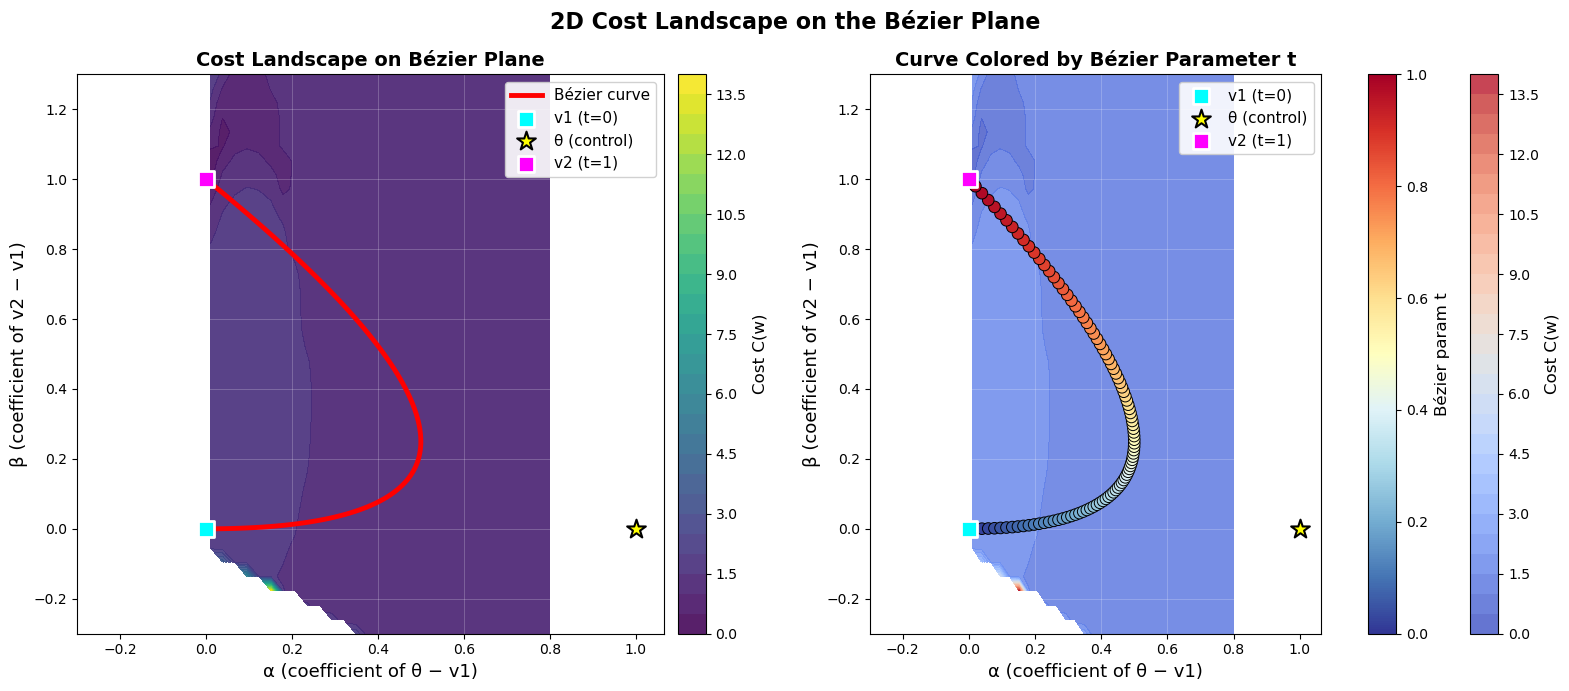


✓ Visualization complete!


In [ ]:
# ============================================================================
# 2D Cost Landscape on Bézier Plane - Standalone Cell
# ============================================================================
# Requirements: v1, v2, theta_new, Xavg, trajectory_cost_and_grad_w function
# ============================================================================

import time
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("Computing 2D cost landscape on the Bézier plane")
print("=" * 70)

# Extract numpy arrays from torch tensors
v1_np = v1.cpu().numpy()
v2_np = v2.cpu().numpy()
theta_np = theta_new.cpu().numpy()

# Define plane basis vectors
# u = direction from v1 to theta (control point)
# v = direction from v1 to v2 (endpoint)
u = theta_np - v1_np
v = v2_np - v1_np
origin = v1_np

print(f"\nPlane basis vectors:")
print(f"  u (v1→θ) norm:  {np.linalg.norm(u):.3e}")
print(f"  v (v1→v2) norm: {np.linalg.norm(v):.3e}")

# Bézier curve parametrization in (alpha, beta) coordinates
# For Bézier parameter t ∈ [0,1]:
#   Point = (1-t)²v1 + 2t(1-t)θ + t²v2
#        = v1 + 2t(1-t)(θ-v1) + t²(v2-v1)
#        = v1 + alpha*u + beta*v
# where: alpha = 2t(1-t), beta = t²

n_curve = 100
t_vals = np.linspace(0, 1, n_curve)
alpha_curve = 2 * t_vals * (1 - t_vals)
beta_curve = t_vals**2

print(f"\nCurve in plane coordinates:")
print(f"  alpha range: [{alpha_curve.min():.3f}, {alpha_curve.max():.3f}]")
print(f"  beta range:  [{beta_curve.min():.3f}, {beta_curve.max():.3f}]")

# Define grid with padding around curve
pad_alpha = 0.3
pad_beta = 0.3
alpha_min = alpha_curve.min() - pad_alpha
alpha_max = alpha_curve.max() + pad_alpha
beta_min = beta_curve.min() - pad_beta
beta_max = beta_curve.max() + pad_beta

# Create grid
n_grid = 40
alpha_grid = np.linspace(alpha_min, alpha_max, n_grid)
beta_grid = np.linspace(beta_min, beta_max, n_grid)
ALPHA, BETA = np.meshgrid(alpha_grid, beta_grid)

print(f"\nGrid setup:")
print(f"  Size: {n_grid} × {n_grid} = {n_grid**2} points")
print(f"  Alpha: [{alpha_min:.3f}, {alpha_max:.3f}]")
print(f"  Beta:  [{beta_min:.3f}, {beta_max:.3f}]")

# Compute cost at each grid point
Cost_grid = np.full((n_grid, n_grid), np.nan)
n_invalid = 0

print(f"\nStarting grid evaluation...")
print("=" * 70)
start_time = time.time()
neg_counts = np.zeros(len(v1_np), dtype=int)  # define before the loop

for i in range(n_grid):
    row_start = time.time()
    
    for j in range(n_grid):
        # Convert (alpha, beta) to 11D parameter vector
        # w = v1 + alpha*u + beta*v
        w_np = origin + ALPHA[i, j] * u + BETA[i, j] * v
        
        # Check for negative parameters (physically invalid)
        if np.any(w_np < 0):
            n_invalid += 1
            neg_idx = np.where(w_np < 0)[0]
            neg_counts[neg_idx] += 1
            continue  # Leave as NaN

        
        # Convert to torch tensor and compute cost
        w_torch = torch.tensor(w_np, dtype=dtype, device=device)
        C, _ = trajectory_cost_and_grad_w(w_torch, Xavg)
        Cost_grid[i, j] = C.item()
    
    # Progress report
    if (i + 1) % 5 == 0 or i == 0:
        row_time = time.time() - row_start
        elapsed = time.time() - start_time
        progress = (i + 1) / n_grid
        eta = (elapsed / progress - elapsed) if progress > 0 else 0
        
        print(f"Row {i+1:2d}/{n_grid} | "
              f"Row time: {row_time:.2f}s | "
              f"Elapsed: {elapsed/60:.1f}min | "
              f"ETA: {eta/60:.1f}min")

total_time = time.time() - start_time
print("=" * 70)
print(f"✓ Grid evaluation complete!")
print(f"  Total time: {total_time/60:.1f} minutes")
print(f"  Points computed: {np.sum(~np.isnan(Cost_grid))}/{n_grid**2}")
print(f"  Invalid points (negative params): {n_invalid}")
print(f"  Cost range: [{np.nanmin(Cost_grid):.3e}, {np.nanmax(Cost_grid):.3e}]")
print("Negative-trigger counts per param index:", neg_counts)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Mask NaN values for plotting
Cost_masked = np.ma.masked_invalid(Cost_grid)

# Left plot: Filled contours with curve overlay
levels = 30
contour1 = ax1.contourf(ALPHA, BETA, Cost_masked, levels=levels, cmap='viridis', alpha=0.9)
ax1.plot(alpha_curve, beta_curve, 'r-', linewidth=3.5, label='Bézier curve', zorder=5)
ax1.scatter([0], [0], c='cyan', s=120, marker='s', edgecolors='white', 
            linewidths=2, label='v1 (t=0)', zorder=6)
ax1.scatter([1], [0], c='yellow', s=200, marker='*', edgecolors='black',
            linewidths=1.5, label='θ (control)', zorder=6)
ax1.scatter([0], [1], c='magenta', s=120, marker='s', edgecolors='white',
            linewidths=2, label='v2 (t=1)', zorder=6)
ax1.set_xlabel('α (coefficient of θ − v1)', fontsize=13)
ax1.set_ylabel('β (coefficient of v2 − v1)', fontsize=13)
ax1.set_title('Cost Landscape on Bézier Plane', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best', framealpha=0.9)
ax1.grid(True, alpha=0.3, color='white', linewidth=0.5)
cbar1 = fig.colorbar(contour1, ax=ax1, pad=0.02)
cbar1.set_label('Cost C(w)', fontsize=12)

# Right plot: Curve colored by Bézier parameter
contour2 = ax2.contourf(ALPHA, BETA, Cost_masked, levels=levels, cmap='coolwarm', alpha=0.8)
scatter = ax2.scatter(alpha_curve, beta_curve, c=t_vals, cmap='RdYlBu_r',
                     s=70, edgecolor='black', linewidth=0.7, zorder=5)
ax2.scatter([0], [0], c='cyan', s=120, marker='s', edgecolors='white',
            linewidths=2, label='v1 (t=0)', zorder=6)
ax2.scatter([1], [0], c='yellow', s=200, marker='*', edgecolors='black',
            linewidths=1.5, label='θ (control)', zorder=6)
ax2.scatter([0], [1], c='magenta', s=120, marker='s', edgecolors='white',
            linewidths=2, label='v2 (t=1)', zorder=6)
ax2.set_xlabel('α (coefficient of θ − v1)', fontsize=13)
ax2.set_ylabel('β (coefficient of v2 − v1)', fontsize=13)
ax2.set_title('Curve Colored by Bézier Parameter t', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11, loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3, color='white', linewidth=0.5)
cbar2 = fig.colorbar(contour2, ax=ax2, pad=0.02)
cbar2.set_label('Cost C(w)', fontsize=12)
cbar_t = fig.colorbar(scatter, ax=ax2, pad=0.08)
cbar_t.set_label('Bézier param t', fontsize=12)

plt.suptitle('2D Cost Landscape on the Bézier Plane', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")



Spatial distribution of negative parameters

k2 (index 1):
  Negative in 440 cells
  α range: [-0.300, -0.018]
  β range: [-0.300, 1.300]

k4 (index 3):
  Negative in 2 cells
  α range: [-0.300, -0.272]
  β range: [-0.300, -0.300]

k4prime (index 4):
  Negative in 70 cells
  α range: [-0.300, -0.215]
  β range: [0.192, 1.300]

k5_minusP (index 5):
  Negative in 440 cells
  α range: [-0.300, -0.018]
  β range: [-0.300, 1.300]

k7 (index 7):
  Negative in 132 cells
  α range: [-0.300, 0.320]
  β range: [-0.300, 0.110]


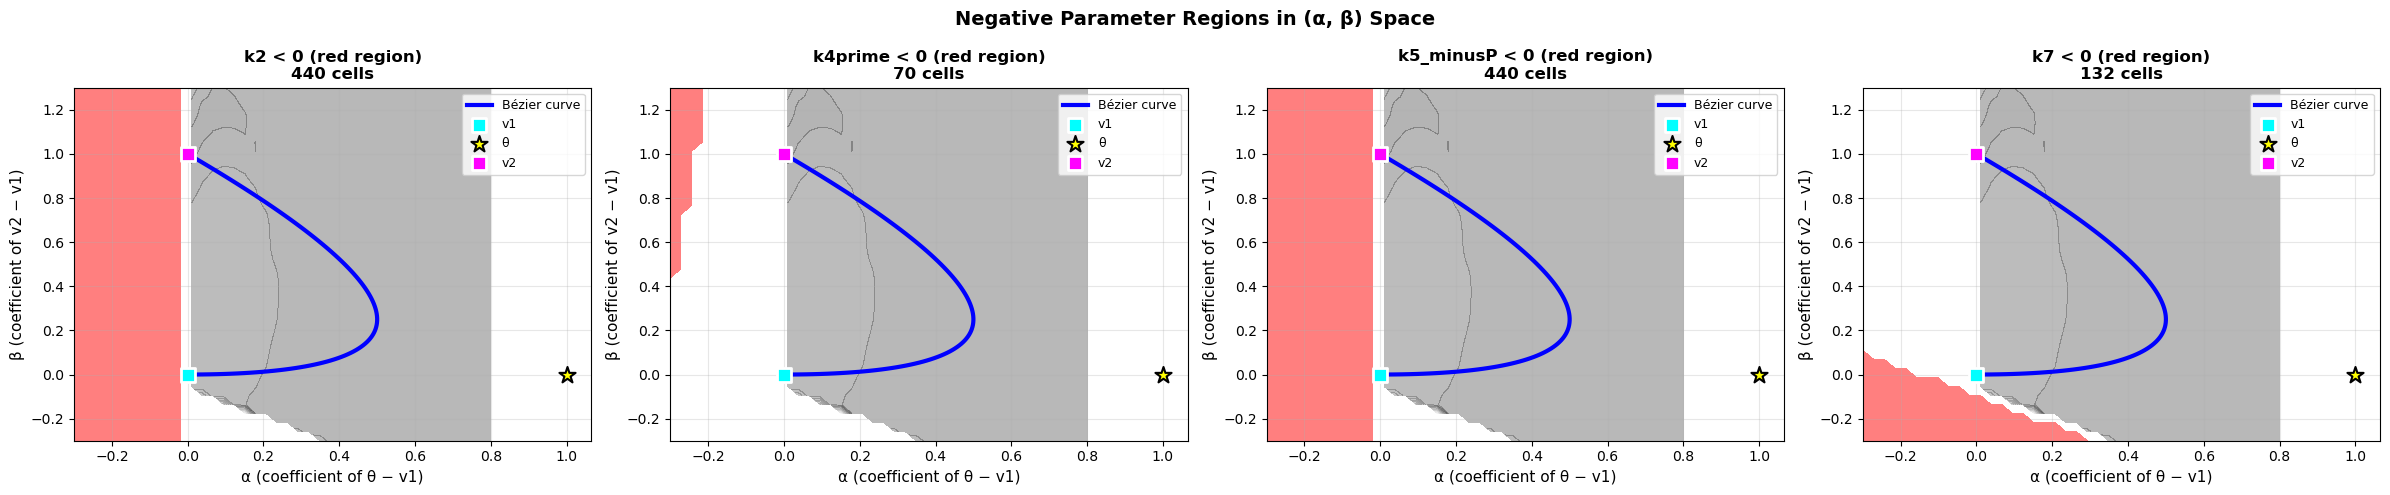

In [14]:
# After the grid computation, add this analysis:

# ============================================================================
# Analyze WHERE in (α, β) space parameters go negative
# ============================================================================

print("\n" + "=" * 70)
print("Spatial distribution of negative parameters")
print("=" * 70)

# Create a mask for each problematic parameter
param_names = ['k1_aa_over_CT', 'k2', 'k3_CT', 'k4', 'k4prime', 'k5_minusP', 
               'k6', 'k7', 'k8_minusP', 'k9', 'CT']

# Find which parameters went negative and where
neg_masks = {}
for idx, name in enumerate(param_names):
    if neg_counts[idx] > 0:
        # Create mask for this parameter
        mask = np.zeros_like(ALPHA, dtype=bool)
        for i in range(n_grid):
            for j in range(n_grid):
                w_np = origin + ALPHA[i, j] * u + BETA[i, j] * v
                if w_np[idx] < 0:
                    mask[i, j] = True
        neg_masks[name] = mask
        
        # Find the (α, β) region
        alpha_neg = ALPHA[mask]
        beta_neg = BETA[mask]
        
        print(f"\n{name} (index {idx}):")
        print(f"  Negative in {mask.sum()} cells")
        print(f"  α range: [{alpha_neg.min():.3f}, {alpha_neg.max():.3f}]")
        print(f"  β range: [{beta_neg.min():.3f}, {beta_neg.max():.3f}]")

# ============================================================================
# Visualize negative parameter regions
# ============================================================================

# Plot the most problematic parameters
plot_params = [(idx, name) for idx, name in enumerate(param_names) if neg_counts[idx] > 50]

if len(plot_params) > 0:
    n_plots = len(plot_params)
    fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))
    if n_plots == 1:
        axes = [axes]
    
    for ax, (idx, name) in zip(axes, plot_params):
        # Show where this parameter is negative
        mask = neg_masks[name]
        
        # Create a masked array: 1 where negative, NaN elsewhere
        neg_overlay = np.full_like(ALPHA, np.nan)
        neg_overlay[mask] = 1.0
        
        # Plot cost landscape in background
        ax.contourf(ALPHA, BETA, Cost_masked, levels=20, cmap='gray', alpha=0.3)
        
        # Overlay negative regions in red
        ax.contourf(ALPHA, BETA, neg_overlay, levels=[0.5, 1.5], colors=['red'], alpha=0.5)
        
        # Plot the Bézier curve
        ax.plot(alpha_curve, beta_curve, 'b-', linewidth=3, label='Bézier curve', zorder=5)
        
        # Mark endpoints
        ax.scatter([0], [0], c='cyan', s=100, marker='s', edgecolors='white', 
                  linewidths=2, label='v1', zorder=6)
        ax.scatter([1], [0], c='yellow', s=150, marker='*', edgecolors='black',
                  linewidths=1.5, label='θ', zorder=6)
        ax.scatter([0], [1], c='magenta', s=100, marker='s', edgecolors='white',
                  linewidths=2, label='v2', zorder=6)
        
        ax.set_xlabel('α (coefficient of θ − v1)', fontsize=11)
        ax.set_ylabel('β (coefficient of v2 − v1)', fontsize=11)
        ax.set_title(f'{name} < 0 (red region)\n{mask.sum()} cells', 
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Negative Parameter Regions in (α, β) Space', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)

Computing 2D cost landscape on the Bézier plane

Plane basis vectors:
  u (v1→θ_opt) norm:  2.430e+02
  v (v1→v2) norm:     4.974e+02

Optimized curve in plane coordinates:
  alpha range: [0.000, 0.500]
  beta range:  [0.000, 1.000]

Grid setup:
  Size: 40 × 40 = 1600 points
  Alpha: [-0.200, 0.700]
  Beta:  [-0.200, 1.200]

Starting grid evaluation...
Row  1/40 | Row time: 75.84s | Elapsed: 1.3min | ETA: 49.3min
Row  5/40 | Row time: 78.14s | Elapsed: 6.4min | ETA: 44.5min
Row 10/40 | Row time: 81.71s | Elapsed: 13.1min | ETA: 39.4min
Row 15/40 | Row time: 88.95s | Elapsed: 20.3min | ETA: 33.8min
Row 20/40 | Row time: 88.22s | Elapsed: 27.7min | ETA: 27.7min
Row 25/40 | Row time: 89.92s | Elapsed: 35.2min | ETA: 21.1min
Row 30/40 | Row time: 88.89s | Elapsed: 42.7min | ETA: 14.2min
Row 35/40 | Row time: 87.26s | Elapsed: 50.0min | ETA: 7.1min
Row 40/40 | Row time: 82.71s | Elapsed: 57.0min | ETA: 0.0min
✓ Grid evaluation complete!
  Total time: 57.0 minutes
  Points computed: 1600/160

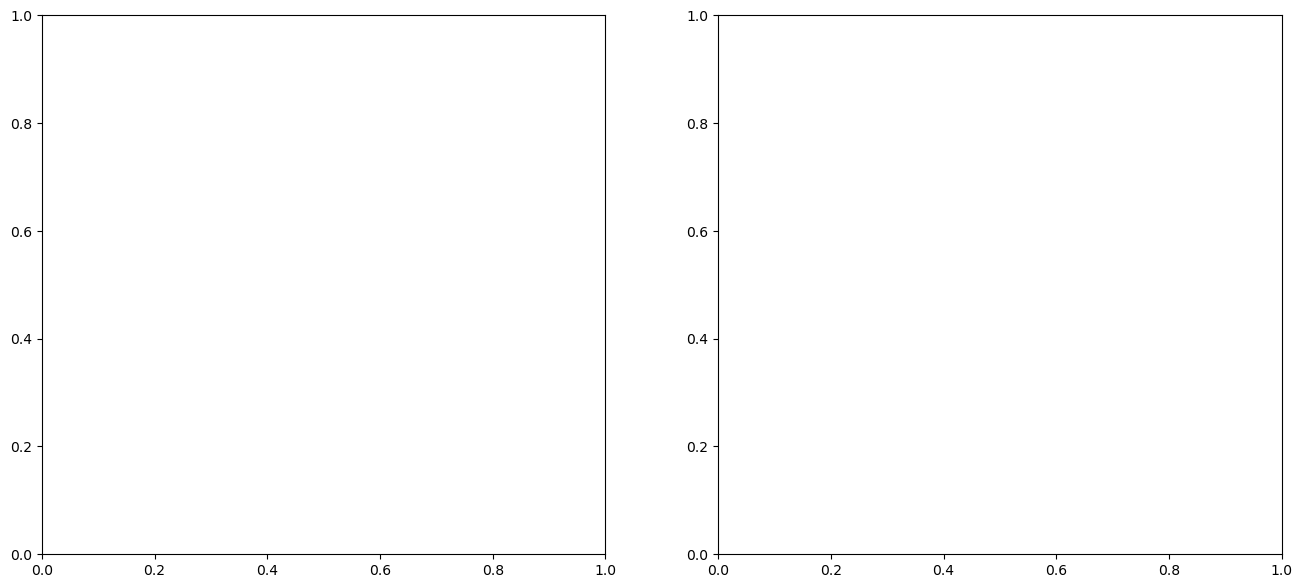

In [ ]:
# ============================================================================
# 2D Cost Landscape on Bézier Plane - Multiple Curves Comparison
# ============================================================================
# Requirements: v1, v2, theta_new, Xavg, trajectory_cost_and_grad_w function
# Compares: optimized theta, random theta, and straight line (midpoint)
# ============================================================================

import time
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("Computing 2D cost landscape on the Bézier plane")
print("=" * 70)

# Define the three control points to compare
theta_opt = theta_new  # Your optimized theta

torch.manual_seed(SEED + 1)  # Different seed for random comparison
theta_mid = 0.5 * (v1 + v2)
theta_rand = (theta_mid + 0.2 * (v2 - v1) * torch.randn_like(v1)).clone().to(device)
# NO clamping - allow negative values
theta_line = theta_mid.clone().to(device)

# Extract numpy arrays from torch tensors
v1_np = v1.cpu().numpy()
v2_np = v2.cpu().numpy()

# We'll compute the plane based on theta_opt
theta_np = theta_opt.cpu().numpy()

# Define plane basis vectors
# u = direction from v1 to theta (control point)
# v = direction from v1 to v2 (endpoint)
u = theta_np - v1_np
v = v2_np - v1_np
origin = v1_np

print(f"\nPlane basis vectors:")
print(f"  u (v1→θ_opt) norm:  {np.linalg.norm(u):.3e}")
print(f"  v (v1→v2) norm:     {np.linalg.norm(v):.3e}")

# Bézier curve parametrization in (alpha, beta) coordinates
# For Bézier parameter t ∈ [0,1]:
#   Point = (1-t)²v1 + 2t(1-t)θ + t²v2
#        = v1 + 2t(1-t)(θ-v1) + t²(v2-v1)
#        = v1 + alpha*u + beta*v
# where: alpha = 2t(1-t), beta = t²

n_curve = 100
t_vals = np.linspace(0, 1, n_curve)
alpha_curve = 2 * t_vals * (1 - t_vals)
beta_curve = t_vals**2

# Compute curve coordinates for all three control points
def get_curve_coords(theta_ctrl):
    """Project a Bézier curve onto the (alpha, beta) plane."""
    theta_np = theta_ctrl.cpu().numpy()
    # For each t, compute the point and project onto plane basis
    coords = []
    for t in t_vals:
        # Bézier point
        point = (1-t)**2 * v1_np + 2*t*(1-t) * theta_np + t**2 * v2_np
        # Project onto plane: point = origin + alpha*u + beta*v
        # Solve: point - origin = alpha*u + beta*v
        rel_point = point - origin
        # If u and v are orthogonal, this is easy. Otherwise solve 2x2 system
        # Use least squares: [u, v] @ [alpha, beta]^T = rel_point
        A = np.column_stack([u, v])
        coeffs, _, _, _ = np.linalg.lstsq(A, rel_point, rcond=None)
        coords.append(coeffs)
    return np.array(coords)

curve_opt = get_curve_coords(theta_opt)
curve_rand = get_curve_coords(theta_rand)
curve_line = get_curve_coords(theta_line)

print(f"\nOptimized curve in plane coordinates:")
print(f"  alpha range: [{curve_opt[:, 0].min():.3f}, {curve_opt[:, 0].max():.3f}]")
print(f"  beta range:  [{curve_opt[:, 1].min():.3f}, {curve_opt[:, 1].max():.3f}]")

# Define grid bounds to encompass ALL three curves
all_alphas = np.concatenate([curve_opt[:, 0], curve_rand[:, 0], curve_line[:, 0]])
all_betas = np.concatenate([curve_opt[:, 1], curve_rand[:, 1], curve_line[:, 1]])

pad_alpha = 0.2
pad_beta = 0.2
alpha_min = all_alphas.min() - pad_alpha
alpha_max = all_alphas.max() + pad_alpha
beta_min = all_betas.min() - pad_beta
beta_max = all_betas.max() + pad_beta

# Create grid
n_grid = 40
alpha_grid = np.linspace(alpha_min, alpha_max, n_grid)
beta_grid = np.linspace(beta_min, beta_max, n_grid)
ALPHA, BETA = np.meshgrid(alpha_grid, beta_grid)

print(f"\nGrid setup:")
print(f"  Size: {n_grid} × {n_grid} = {n_grid**2} points")
print(f"  Alpha: [{alpha_min:.3f}, {alpha_max:.3f}]")
print(f"  Beta:  [{beta_min:.3f}, {beta_max:.3f}]")

# Compute cost at each grid point (NO clamping - allow negative parameters)
Cost_grid = np.full((n_grid, n_grid), np.nan)
n_invalid = 0

print(f"\nStarting grid evaluation...")
print("=" * 70)
start_time = time.time()

for i in range(n_grid):
    row_start = time.time()
    
    for j in range(n_grid):
        # Convert (alpha, beta) to 11D parameter vector
        # w = v1 + alpha*u + beta*v
        w_np = origin + ALPHA[i, j] * u + BETA[i, j] * v
        
        # NO negative check - allow all parameter values
        # Convert to torch tensor and compute cost
        try:
            w_torch = torch.tensor(w_np, dtype=dtype, device=device)
            C, _ = trajectory_cost_and_grad_w(w_torch, Xavg)
            Cost_grid[i, j] = C.item()
        except:
            # If integration fails, leave as NaN
            n_invalid += 1
            continue
    
    # Progress report
    if (i + 1) % 5 == 0 or i == 0:
        row_time = time.time() - row_start
        elapsed = time.time() - start_time
        progress = (i + 1) / n_grid
        eta = (elapsed / progress - elapsed) if progress > 0 else 0
        
        print(f"Row {i+1:2d}/{n_grid} | "
              f"Row time: {row_time:.2f}s | "
              f"Elapsed: {elapsed/60:.1f}min | "
              f"ETA: {eta/60:.1f}min")

total_time = time.time() - start_time
print("=" * 70)
print(f"✓ Grid evaluation complete!")
print(f"  Total time: {total_time/60:.1f} minutes")
print(f"  Points computed: {np.sum(~np.isnan(Cost_grid))}/{n_grid**2}")
print(f"  Failed points: {n_invalid}")
print(f"  Cost range: [{np.nanmin(Cost_grid):.3e}, {np.nanmax(Cost_grid):.3e}]")




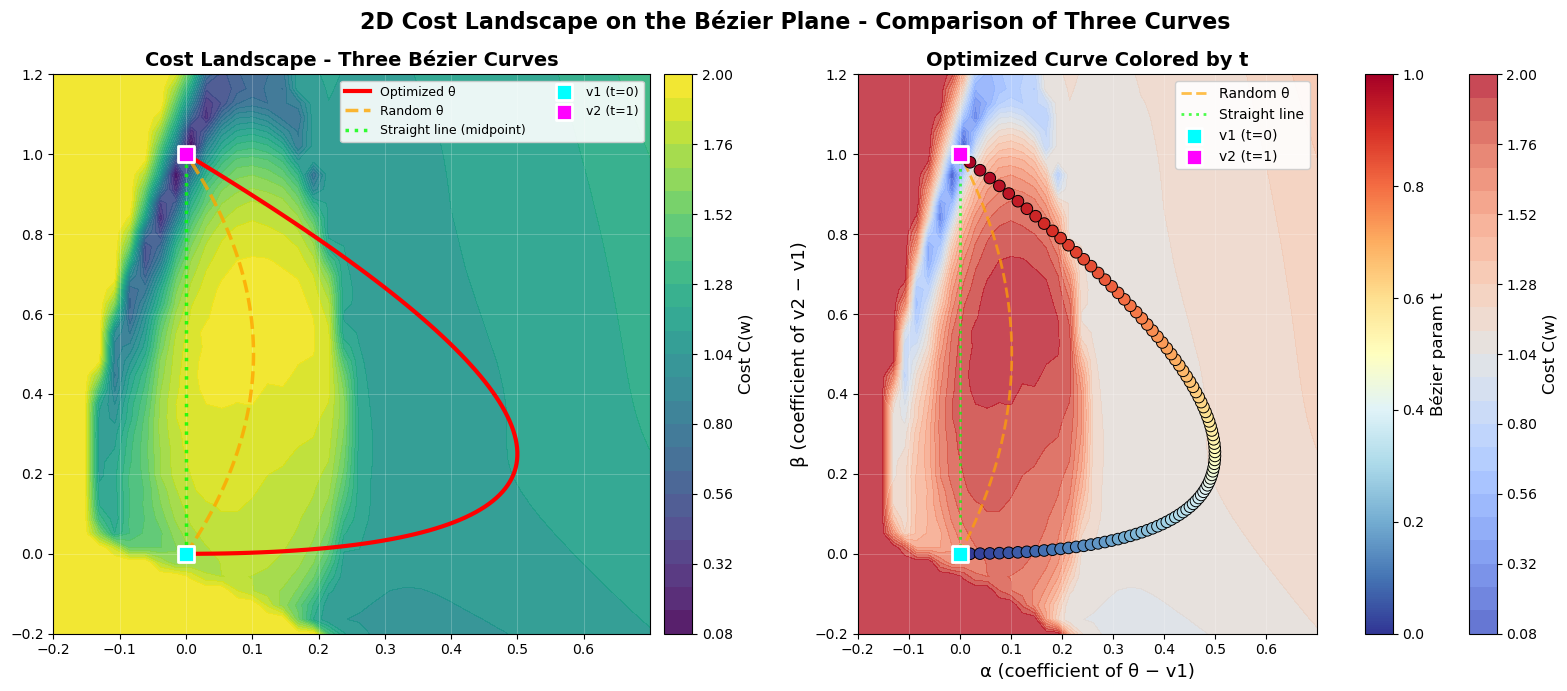


✓ Visualization complete!


In [21]:
# Create visualization with all three curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# Mask NaN values for plotting
Cost_masked = np.ma.masked_invalid(Cost_grid)
COST_MAX = 2.0
Cost_clipped = np.clip(Cost_grid, None, COST_MAX)
Cost_clipped_masked = np.ma.masked_invalid(Cost_clipped)

# Left plot: Filled contours with all three curves
levels = 30
contour1 = ax1.contourf(ALPHA, BETA, Cost_clipped_masked, levels=levels, cmap='viridis', alpha=0.9)

# Plot all three Bézier curves
ax1.plot(curve_opt[:, 0], curve_opt[:, 1], 'r-', linewidth=3, label='Optimized θ', zorder=5)
ax1.plot(curve_rand[:, 0], curve_rand[:, 1], 'orange', linewidth=2.5, linestyle='--', 
         label='Random θ', zorder=5, alpha=0.8)
ax1.plot(curve_line[:, 0], curve_line[:, 1], 'lime', linewidth=2.5, linestyle=':', 
         label='Straight line (midpoint)', zorder=5, alpha=0.8)

# Mark control points
ax1.scatter([0], [0], c='cyan', s=120, marker='s', edgecolors='white', 
            linewidths=2, label='v1 (t=0)', zorder=6)
ax1.scatter([0], [1], c='magenta', s=120, marker='s', edgecolors='white',
            linewidths=2, label='v2 (t=1)', zorder=6)


ax1.set_title('Cost Landscape - Three Bézier Curves', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='best', framealpha=0.9, ncol=2)
ax1.grid(True, alpha=0.3, color='white', linewidth=0.5)
cbar1 = fig.colorbar(contour1, ax=ax1, pad=0.02)
cbar1.set_label('Cost C(w)', fontsize=12)

# Right plot: Optimized curve colored by Bézier parameter
contour2 = ax2.contourf(ALPHA, BETA, Cost_clipped_masked, levels=levels, cmap='coolwarm', alpha=0.8)

# Optimized curve with color gradient
scatter = ax2.scatter(curve_opt[:, 0], curve_opt[:, 1], c=t_vals, cmap='RdYlBu_r',
                     s=70, edgecolor='black', linewidth=0.7, zorder=5)

# Other curves as simple lines
ax2.plot(curve_rand[:, 0], curve_rand[:, 1], 'orange', linewidth=2, linestyle='--', 
         label='Random θ', zorder=4, alpha=0.7)
ax2.plot(curve_line[:, 0], curve_line[:, 1], 'lime', linewidth=2, linestyle=':', 
         label='Straight line', zorder=4, alpha=0.7)

ax2.scatter([0], [0], c='cyan', s=120, marker='s', edgecolors='white',
            linewidths=2, label='v1 (t=0)', zorder=6)
ax2.scatter([0], [1], c='magenta', s=120, marker='s', edgecolors='white',
            linewidths=2, label='v2 (t=1)', zorder=6)

ax2.set_xlabel('α (coefficient of θ − v1)', fontsize=13)
ax2.set_ylabel('β (coefficient of v2 − v1)', fontsize=13)
ax2.set_title('Optimized Curve Colored by t', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='best', framealpha=0.9)
ax2.grid(True, alpha=0.3, color='white', linewidth=0.5)
cbar2 = fig.colorbar(contour2, ax=ax2, pad=0.02)
cbar2.set_label('Cost C(w)', fontsize=12)
cbar_t = fig.colorbar(scatter, ax=ax2, pad=0.08)
cbar_t.set_label('Bézier param t', fontsize=12)

plt.suptitle('2D Cost Landscape on the Bézier Plane - Comparison of Three Curves', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")